In [2]:
import numpy as np
import pandas as pd
import sklearn.model_selection
import argparse, os, glob, re, warnings, shutil, pysam, vcf, subprocess
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
import statsmodels.api as sm
from Bio import Seq, SeqIO
import scipy.stats as st
import sys
sys.path.append("variantDetector")
from utils import *

df_isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/combined_patient_WGS_data.csv")

df_assemblies = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv")
df_ASM_QC = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/hybridASM_QC.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID
        
    if not pd.isnull(row['Lineage']):
        if type(row['Lineage']) == float:
            df_trust_patients.loc[i, 'Lineage'] = str(int(row['Lineage']))
        else:
            df_trust_patients.loc[i, 'Lineage'] = str(row['Lineage'])
     
print(df_trust_patients.Lineage.value_counts())
            
F2_max = 0.03
h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

genomic_data_dir = "/n/data1/hms/dbmi/farhat/rollingDB/genomic_data"

LinToColor_Dict = {"1": "#DF83AC",
                   "2": "#7098CB",
                   "3": "#815D9F",
                   "4": "#E76956",
                  }

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

# remove rRNAs, which are highly conserved. rrs, rrl, and rrf
rRNA_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='stable RNAs' & Feature=='rRNA'").iterrows():
    print(row['Name'])
    rRNA_pos += list(np.arange(row['Start'], row['Stop'] + 1))
    
insertion_seqs_phages_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='insertion seqs and phages'").iterrows():
    insertion_seqs_phages_pos += list(np.arange(row['Start'], row['Stop'] + 1))
    
insertion_seqs_phages_pos = np.unique(insertion_seqs_phages_pos)

Lineage
2      381
4      330
3       48
2,4      6
1        1
2,3      1
Name: count, dtype: int64
rrs
rrl
rrf


In [3]:
model_dir = "./variantDetector/unmixed_only_clean"

df_train = pd.read_csv(f"{model_dir}/training_data_with_predictions.csv")

In [8]:
df_train.query("POS==2873110")[['SampleID', 'POS', 'REF', 'ALT', 'AF', 'SAF', 'SAR', 'SAF_prop_deviation_from_half', 'pred_class']].merge(df_trust_patients[['SampleID', 'Coll2014']])

,SampleID,POS,REF,ALT,AF,SAF,SAR,SAF_prop_deviation_from_half,pred_class,Coll2014
0,MFS-135,2873110,G,C,0.068966,4,12,0.250000,0,3
1,MFS-15,2873110,G,C,0.065574,6,6,0.000000,1,3
2,MFS-430,2873110,G,C,0.060109,4,7,0.136364,1,4.3.3
3,MFS-482,2873110,G,C,0.060241,4,6,0.100000,1,4.3.3
4,MFS-566,2873110,G,C,0.065574,8,4,0.166667,1,3
5,MFS-611,2873110,G,C,0.067669,2,7,0.277778,0,2.2.1


In [5]:
# needing to right-align indels is a problem
# MFS-15 2873110 is near an indel, and the only reads supporting it are too short to cover the indel

# false variants caused by proxomity to a simple sequence repeat or a duplication: 2873110, 3462159, 33207, 176433, 4130682, 4130683, 4130694

df_train.query("pred_class==1 & Real==0 & AF > 0.06 & POS in [2873110, 3462159, 33207, 176433]")[['SampleID', 'POS', 'REF', 'ALT', 'AF', 'SAF_prop_deviation_from_half', 'COV_RATIO', 'NEG_COV_RATIO', 'POS_COV_RATIO', 'DISCORDANT_READS_RATIO',
       'CLIPPED_BASES_RATIO', 'Real', 'predicted', 'pred_class']].sort_values('POS').query("SampleID != 'MFS-310'")

,SampleID,POS,REF,ALT,AF,SAF_prop_deviation_from_half,COV_RATIO,NEG_COV_RATIO,POS_COV_RATIO,DISCORDANT_READS_RATIO,CLIPPED_BASES_RATIO,Real,predicted,pred_class
273,MFS-277,33207,G,C,0.080569,0.029412,0.943461,0.056539,0.000000,0.025455,0.003636,0,0.955473,1
559,MFS-429,176433,C,A,0.081395,0.023810,0.963313,0.036687,0.000000,0.009740,0.006494,0,0.984855,1
116,MFS-15,2873110,G,C,0.065574,0.000000,0.945167,0.054833,0.000000,0.006969,0.013937,0,0.971608,1
567,MFS-430,2873110,G,C,0.060109,0.136364,0.967681,0.032319,0.000000,0.013072,0.013072,0,0.832629,1
587,MFS-482,2873110,G,C,0.060241,0.100000,0.974528,0.025472,0.000000,0.010345,0.017241,0,0.862574,1
637,MFS-566,2873110,G,C,0.065574,0.166667,1.006847,0.000000,0.006847,0.003636,0.018182,0,0.650208,1
326,MFS-309,3462159,A,G,0.090909,0.071429,0.864921,0.135079,0.000000,0.021858,0.021858,0,0.805566,1
564,MFS-429,3462159,A,G,0.078431,0.125000,0.919296,0.080704,0.000000,0.024038,0.024038,0,0.663687,1
597,MFS-513,3462159,A,G,0.074830,0.136364,0.924982,0.075018,0.000000,0.004082,0.024490,0,0.685679,1
779,MFS-755,3462159,A,G,0.069767,0.166667,0.970728,0.029272,0.000000,0.015504,0.031008,0,0.761445,1


In [14]:
# del_fNames = glob.glob(f"{personal_ref_dir}/*/pilon/confusion_matrix.csv")
# len(del_fNames)

179

In [15]:
# for fName in del_fNames:
#     os.remove(fName)

In [189]:
pilon_model = "./pilonVariantDetector/unmixed_only"

df_train_pilon = pd.read_csv(f"{pilon_model}/training_data_with_predictions.csv")
df_val_pilon = pd.read_csv(f"{pilon_model}/validation_data_with_predictions.csv")

freebayes_model = "./variantDetector/unmixed_only"

df_train_FB = pd.read_csv(f"{freebayes_model}/training_data_with_predictions_fixed.csv")
df_val_FB = pd.read_csv(f"{freebayes_model}/validation_data_with_predictions_fixed.csv")

len(df_val_pilon)



2098

In [95]:
len(df_train_FB)

946

In [190]:
len(df_train_FB.query("pred_class==1 & Real==0")), len(df_train_FB.query("pred_class==0 & Real==1"))

(60, 22)

In [194]:
df_train_FB.query("pred_class==1 & Real==0 & GENE not in ['Rv2082', 'Rv2081c']")[['SampleID', 'POS', 'REF', 'ALT', 'AF', 'GENE']]

,SampleID,POS,REF,ALT,AF,GENE
185,MFS-160,3717219,C,G,0.139073,sugI
203,MFS-163,554179,C,G,0.054054,Rv0463
299,MFS-27,4211206,G,A,0.050193,tcrX
340,MFS-307,467579,G,A,0.056738,PPE9
347,MFS-307,4316315,G,C,0.161017,Rv3843c
370,MFS-310,4130682,A,G,0.320690,Rv3689
371,MFS-310,4130683,T,C,0.320690,Rv3689
372,MFS-310,4130694,T,C,0.324590,Rv3689
375,MFS-311,727556,G,C,0.055556,recC
387,MFS-314,554179,C,G,0.074468,Rv0463


In [89]:
df_train_FB[['SampleID', 'POS', 'pred_class', 'Real']][['pred_class', 'Real']].value_counts()

pred_class  Real
0           0       539
1           1       381
0           1        13
1           0        13
Name: count, dtype: int64

In [120]:
sample = 'MFS-307'
df_vars = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.split.fixedAO.final.v2.tsv", sep='\t')
df_vars['SampleID'] = sample

In [121]:
df_vars.query("POS in [467579, 4316314]")

,POS,REF,ALT,QUAL,FILTER,NS,DP,DPB,AC,AN,...,PAIRED,PAIREDR,MIN_DP,END,ORIGIN,INV,ANN,LOF,NMD,SampleID
264,467579,G,A,0.0,NaN,1,141,141.0,0,1,...,1.0,1.0,NaN,NaN,NaN,False,A|synonymous_variant|LOW|PPE9|Rv0388c|transcri...,NaN,NaN,MFS-307
2250,4316314,CG,GC,0.0,NaN,1,236,236.0,0,1,...,1.0,1.0,NaN,NaN,Chromosome:4316314,False,GC|missense_variant|MODERATE|Rv3843c|Rv3843c|t...,NaN,NaN,MFS-307


In [132]:
del_files = glob.glob(f"{personal_ref_dir}/*/lowAF_comparison/*old*")
len(del_files)

534

In [128]:
df_samples = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv")

In [140]:
df_samples.to_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv", index=False)

In [122]:
df_split_vars = split_MNPs_into_SNPs(df_vars.query("POS in [467579, 4316314]"))

In [123]:
df_split_vars

,POS,REF,ALT,QUAL,FILTER,NS,DP,DPB,AC,AN,...,PAIRED,PAIREDR,MIN_DP,END,ORIGIN,INV,ANN,LOF,NMD,SampleID
0,467579,G,A,0.0,NaN,1,141,141.0,0,1,...,1.0,1.0,NaN,NaN,NaN,False,A|synonymous_variant|LOW|PPE9|Rv0388c|transcri...,NaN,NaN,MFS-307
1,4316314,C,G,0.0,NaN,1,236,236.0,0,1,...,1.0,1.0,NaN,NaN,Chromosome:4316314,False,GC|missense_variant|MODERATE|Rv3843c|Rv3843c|t...,NaN,NaN,MFS-307
2,4316315,G,C,0.0,NaN,1,236,236.0,0,1,...,1.0,1.0,NaN,NaN,Chromosome:4316314,False,GC|missense_variant|MODERATE|Rv3843c|Rv3843c|t...,NaN,NaN,MFS-307


In [2]:
confusion_matrix_files = glob.glob(f"{personal_ref_dir}/*/lowAF_comparison/confusion_matrix.csv")

df_confusion_matrix = []

for fName in confusion_matrix_files:
    df = pd.read_csv(fName)
    df_ground_truth = pd.read_csv(fName.replace('confusion_matrix.csv', 'ground_truth.csv'))
    
    # add the other alignment information to it. It's only in ground_truth.csv, not in confusion_matrix.csv
    df = df.merge(df_ground_truth, on=['POS', 'REF', 'ALT'], how='left')
    
    df['SampleID'] = os.path.basename(os.path.dirname(os.path.dirname(fName)))
    df_confusion_matrix.append(df)
    
# ground truth files include AFs down to 2-98% now, but we're benchmarking 5% minimum
df_confusion_matrix = pd.concat(df_confusion_matrix).query("~(POS >= 2338065 & POS <= 2340874) & ~(AF < 0.05 | AF > 0.95)")

df_confusion_matrix = df_confusion_matrix.merge(df_trust_patients[['SampleID', 'F2']]).query("F2 <= @F2_max")

df_confusion_matrix['Region'] = df_confusion_matrix['POS'].map(h37Rv_coords_dict)

In [3]:
df_confusion_matrix.query("").Result.value_counts()

Result
FP    770
TP    400
Name: count, dtype: int64

In [74]:
df_confusion_matrix.query("~(AF < 0.05 | AF > 0.95)")#.query("Result=='FP'").SampleID.value_counts()

,POS,REF,ALT,H37Rv_POS,H37Rv_REF,H37Rv_ALT,Result,QUAL,FILTER,DP,...,SAR,SRP,SAP,RPP,RPPR,RPL,RPR,SampleID,F2,Region
0,NaN,NaN,NaN,410009.0,T,C,FP,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MFS-1,0.011212,NaN
3,2076862.0,A,G,2076862.0,A,G,TP,1.100000e-14,NaN,257.0,...,11.0,3.74624,4.9405,4.94050,18.28330,7.0,11.0,MFS-1,0.011212,gcvB
4,NaN,NaN,NaN,2591484.0,A,G,FP,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MFS-1,0.011212,NaN
5,NaN,NaN,NaN,2592310.0,A,G,FP,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MFS-1,0.011212,NaN
7,NaN,NaN,NaN,3851887.0,C,A,FP,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MFS-1,0.011212,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9453,NaN,NaN,NaN,1543973.0,C,T,FP,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MFS-97,0.010201,NaN
9454,1844169.0,G,T,1844169.0,G,T,TP,4.300000e-15,NaN,330.0,...,12.0,4.03217,3.0103,6.26751,3.46446,9.0,15.0,MFS-97,0.010201,uvrA
9455,NaN,NaN,NaN,2591484.0,G,A,FP,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MFS-97,0.010201,NaN
9457,NaN,NaN,NaN,3851887.0,C,A,FP,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MFS-97,0.010201,NaN


In [197]:
# df_samples = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples.tsv", sep='\t', header=None)

In [255]:
# df_samples.to_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples.tsv", index=False, sep='\t', header=None)

In [233]:
df_LR_samples = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv")

In [261]:
df_LR_samples.to_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv", index=False)

In [250]:
sample = 'MFS-737'
ground_truth = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/ground_truth.csv")
confusion_matrix = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/confusion_matrix.csv")
H37Rv_detected = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/H37Rv_detected.csv")

In [253]:
ground_truth.query("AF >= 0.05 & AF <= 0.95")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
2,997899,T,C,2.300000e-13,NaN,331,228,103,0.311178,60.0,...,99,129,40,63,11.5819,14.1628,6.5732,3.0103,45.0,58.0


In [254]:
H37Rv_detected.query("~(POS >= 2338065 & POS <= 2340874)")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
0,997899,T,C,4300.0,NaN,329,104.0,225,0.683891,60.0,...,40.0,64.0,97,128,15.0369,12.2849,3.09716,7.10269,114.0,111.0


In [217]:
sample = 'MFS-737'
df_cleaned = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.cleaned.fixedAO.tsv", sep='\t')
# df_cleaned[['AO', 'SAF', 'SAR']] = df_cleaned[['AO', 'SAF', 'SAR']].astype(int)

In [228]:
df_trust_patients.query("SampleID=='MFS-737'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_meth,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week
109,T0096,S0096-01,MFS-737,MFS-737_lib73367,1.0,NaN,1.0,407.83,1.0,0.9873,...,NaN,NaN,2.0,0.659169,NaN,0.011066,3.1.1,3.1.1.i1,3,1


In [229]:
# 1753519 is near an insertion at a homopolymeric tract. The reads supporting G>C are short enough that they don't support the indel. Problems caused by that
df_cleaned.query("AF >= 0.05 & AF <= 0.95 & SAF >= 2 & SAR >= 2 & REF.str.len() == ALT.str.len() & ~(POS >= 2338065 & POS <= 2340874)")[['POS', 'REF', 'ALT', 'AO', 'AF', 'SAF', 'SAR']]

,POS,REF,ALT,AO,AF,SAF,SAR
592,997899,C,T,225,0.683891,97,128
989,1753519,G,C,12,0.061856,3,9


In [232]:
df_cleaned.query("POS==1753519")

,POS,REF,ALT,QUAL,FILTER,NS,DP,DPB,AC,AN,...,MQMR,PAIRED,PAIREDR,MIN_DP,END,ORIGIN,INV,ANN,LOF,NMD
989,1753519,G,C,6400.0,NaN,1.0,194,220.714,0.0,1.0,...,0.0,"0.994475,1",0.0,NaN,NaN,Chromosome:1753519,False,C|missense_variant|MODERATE|fadD11.1|Rv1549|tr...,NaN,NaN
990,1753519,G,GC,6400.0,NaN,1.0,194,220.714,1.0,1.0,...,0.0,"0.994475,1",0.0,NaN,NaN,Chromosome:1753519,False,GC|frameshift_variant|HIGH|fadD11.1|Rv1549|tra...,NaN,NaN


In [230]:
unfixed_SNVs_all = pd.read_csv("unfixed_SNVs_all.csv")

In [231]:
unfixed_SNVs_all.query("SampleID==@sample")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,predicted,pred_class,Sampling_Week,SNP,Region,Variant_Type,REF_AA,ALT_AA,GENE1,GENE2
1286,997899,C,T,4300.0,Rv0895,c.118C>T,p.Leu40Leu,1,329,329.0,...,0.043707,0.0,1,997899_C_T,Rv0895,Silent,Leu,Leu,Rv0895,NaN


In [128]:
pos

1849

In [121]:
fixed_outputs_pos_merged

defaultdict(list,
            {(0, 'T', 'C'): [14, 59.785701751708984, 0, 0],
             (4, 'C', 'A'): [15, 59.89285087585449, 0, 0],
             (5, 'T', 'C'): [30, 59.928567250569664, 11, 11],
             (6, 'G', 'C'): [30, 59.928567250569664, 11, 11],
             (7, 'G', 'C'): [15, 59.89285087585449, 0, 0],
             (8, 'G', 'A'): [30, 59.928567250569664, 11, 11],
             (0, 'T', 'G'): [1, 60.0, 0, 0]})

In [117]:
for key in new_record.info.keys():
    print(key, new_record.info[key])

In [119]:
new_record#.info['AO']

In [98]:
new_AO

14

In [93]:
fixed_outputs_pos_merged.keys()

dict_keys([(0, 'T', 'C'), (4, 'C', 'A'), (5, 'T', 'C'), (6, 'G', 'C'), (7, 'G', 'C'), (8, 'G', 'A'), (0, 'T', 'G')])

In [92]:
fixed_outputs_pos_merged

defaultdict(list,
            {(0, 'T', 'C'): [14, 59.785701751708984, 0, 0],
             (4, 'C', 'A'): [15, 59.89285087585449, 0, 0],
             (5, 'T', 'C'): [30, 59.928567250569664, 11, 11],
             (6, 'G', 'C'): [30, 59.928567250569664, 11, 11],
             (7, 'G', 'C'): [15, 59.89285087585449, 0, 0],
             (8, 'G', 'A'): [30, 59.928567250569664, 11, 11],
             (0, 'T', 'G'): [1, 60.0, 0, 0]})

In [75]:
def convert_dictionary_to_new_VCF_entries(pos, vals_dict):
    
    # iterate through dictionary
    for key, val in vals_dict.items():

        pos_offset, single_ref, single_alt = key

        single_pos = pos + pos_offset

        return [single_pos, single_ref, single_alt, val]

In [51]:
pos, ref, alts

(104936, 'TGTGCTGGG', ['CGTGACCCA', 'GGTGACCCA', 'TGTGCCCGA'])

In [76]:
fixed_outputs[0]

defaultdict(int,
            {(0, 'T', 'C'): 14,
             (4, 'C', 'A'): 15,
             (5, 'T', 'C'): 30,
             (6, 'G', 'C'): 30,
             (7, 'G', 'C'): 15,
             (8, 'G', 'A'): 30,
             (0, 'T', 'G'): 1})

In [77]:
fixed_outputs[1]

defaultdict(list,
            {(0, 'T', 'C'): [59.785701751708984],
             (4, 'C', 'A'): [59.785701751708984, 60.0],
             (5, 'T', 'C'): [59.785701751708984, 60.0, 60.0],
             (6, 'G', 'C'): [59.785701751708984, 60.0, 60.0],
             (7, 'G', 'C'): [59.785701751708984, 60.0],
             (8, 'G', 'A'): [59.785701751708984, 60.0, 60.0],
             (0, 'T', 'G'): [60.0]})

In [252]:
for i, row in df_idk.query("ALT.str.contains(',')").iterrows():
    
    pos = row['POS']
    ref = row['REF']
    alt_alleles = row['ALT'].split(',')
    cigars = row['CIGAR'].split(',')
    ao_lst = np.array(row['AO'].split(',')).astype(int)
    
    lengths = [len(allele) for allele in alt_alleles]
    
#     # all the same length
#     if len(np.unique(lengths)) == 1 and len(alt_alleles[0]) == len(ref):

#         split_variant_dict = merge_multiallelic_snvs(ref, alt_alleles, ao_lst)
#         reconstructed_vars = reconstruct_mnvs(ref, split_variant_dict)
#         # print(row['POS'], reconstructed_vars)
#     else:
    merged = merge_haplotypes(ref, alt_alleles, cigars, ao_lst)
    print(pos, merged)

24698 [{'edits': {('DEL', 1, 'CCGCGTTGCTCGGGGTAA')}, 'AO': 113}, {'edits': {('SUB', 6, 'T', 'C'), ('SUB', 18, 'A', 'G'), ('SUB', 0, 'G', 'C'), ('SUB', 9, 'C', 'G')}, 'AO': 3}]
28366 [{'edits': {('DEL', 1, 'T')}, 'AO': 242}, {'edits': {('SUB', 1, 'T', 'A')}, 'AO': 4}]
33207 [{'edits': {('INS', 1, 'C')}, 'AO': 15}, {'edits': {('INS', 1, 'GC')}, 'AO': 249}]
104936 [{'edits': {('SUB', 6, 'G', 'C'), ('SUB', 5, 'T', 'C'), ('SUB', 8, 'G', 'A')}, 'AO': 30}]
162151 [{'edits': {('DEL', 1, 'T')}, 'AO': 250}, {'edits': {('SUB', 1, 'T', 'G')}, 'AO': 3}]
163705 [{'edits': {('SUB', 0, 'C', 'T'), ('SUB', 1, 'C', 'T')}, 'AO': 311}]
336047 [{'edits': {('SUB', 3, 'A', 'G'), ('SUB', 6, 'G', 'C')}, 'AO': 4}]
410006 [{'edits': {('DEL', 1, 'GTTGGCGCTGGT')}, 'AO': 140}, {'edits': {('SUB', 3, 'T', 'C')}, 'AO': 14}]
424320 [{'edits': {('INS', 1, 'C')}, 'AO': 260}, {'edits': {('SUB', 0, 'T', 'C')}, 'AO': 6}]
623558 [{'edits': {('DEL', 1, 'ACGGCGGCG')}, 'AO': 36}, {'edits': {('SUB', 10, 'A', 'T'), ('SUB', 17, 'C'

In [236]:
df_idk.query("POS==3851883")

,POS,REF,ALT,AO
2410,3851883,GCCGAT,"CCCGCC,GCCGCC","3,39"


In [228]:
reconstructed_vars

NameError: name 'reconstructed_vars' is not defined

In [223]:
split_variant_dict

In [224]:
 merge_multiallelic_snvs(row['REF'], row['ALT'].split(','), np.array(row['AO'].split(',')).astype(int))

In [225]:
row['ALT'].split(',')

['CCCGCGCTGGTCGGGGTAGC', 'GC']

In [226]:
np.array(row['AO'].split(',')).astype(int)

array([  3, 113])

In [208]:
from collections import defaultdict

def merge_multiallelic_snvs(ref, alts, ao_list):
    """
    Merge multiallelic SNV/MNV alleles that imply the same base changes.

    Parameters
    ----------
    ref : str
        Reference allele
    alts : list[str]
        Alternate alleles
    ao_list : list[int]
        AO values corresponding to each ALT

    Returns
    -------
    dict
        {(pos, ref_base, alt_base): summed_AO}
        where pos is 0-based relative to REF
    """

    # Sanity check: only SNVs/MNVs
    for alt in alts:
        if len(alt) != len(ref):
            return None  # skip indels / complex length changes

    merged = defaultdict(int)

    for alt, ao in zip(alts, ao_list):
        for i, (r, a) in enumerate(zip(ref, alt)):
            if r != a:
                merged[(i, r, a)] += ao

    return merged


In [209]:
def reconstruct_mnvs(ref, merged):
    """
    Rebuild MNVs from merged SNVs.

    Returns
    -------
    dict
        { (start, ref_seq, alt_seq): AO }
    """

    mnvs = defaultdict(list)

    for (pos, r, a), ao in merged.items():
        mnvs[ao].append((pos, r, a))

    rebuilt = {}

    for ao, changes in mnvs.items():
        changes.sort()
        start = changes[0][0]
        end = changes[-1][0] + 1

        ref_seq = list(ref[start:end])
        alt_seq = ref_seq.copy()

        for pos, _, a in changes:
            alt_seq[pos - start] = a

        rebuilt[(start, ''.join(ref_seq), ''.join(alt_seq))] = ao

    return rebuilt


In [192]:
df_train = pd.read_csv("variantDetector/unmixed_only/training_data_with_predictions.csv")

In [200]:
pd.read_csv(f"{H37Rv_ref_dir}/MFS-1/freebayes/MFS-1.excludeLowConf.split.fixedAO.final.tsv", sep='\t').query("AF >= 0.05 & AF <= 0.95")

,POS,REF,ALT,QUAL,FILTER,NS,DP,DPB,AC,AN,...,MEANALT,LEN,MQM,MQMR,PAIRED,PAIREDR,MIN_DP,END,ORIGIN,INV


In [202]:
pd.read_csv(f"{H37Rv_ref_dir}/MFS-1/freebayes/MFS-1.excludeLowConf.split.fixedAO.final.tsv", sep='\t')

,AF
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
1942,1.0
1943,1.0
1944,1.0
1945,1.0


In [167]:
# del_fNames = glob.glob(f"{personal_ref_dir}/*/freebayes/lowAF_variants.bed")

In [168]:
# for fName in del_fNames:
#     os.remove(fName)

In [176]:
sample = 'MFS-1'
lowAF_variants_personal_genome_BED_fName = f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.bed"
lowAF_variants_H37Rv_BED_fName = f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.excludeLowConf.bed"

df_lowAF_variants_personal_asm_personal_coords = pd.read_csv(lowAF_variants_personal_genome_BED_fName, sep='\t')

keep_cols = ['REF', 'ALT', 'QUAL', 'FILTER', 'DP', 'RO', 'AO', 'AF', 'MQM', 'MQMR', 'SRF', 'SRR', 'SAF', 'SAR', 'SRP', 'SAP', 'RPP', 'RPPR', 'RPL', 'RPR']

# there may not be any low AF variants
if len(df_lowAF_variants_personal_asm_personal_coords) > 0:

    # df_lowAF_variants_personal_asm_transferred = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.excludeLowConf.bed", 
    #                                                          sep='\t', 
    #                                                          header=None,
    #                                                          usecols=[0, 1, 2, 3],
    #                                                          names=['H37Rv_CHROM', 'H37Rv_BEG', 'H37Rv_END', 'Combined_Personal']
    #                                             )

    df_lowAF_variants_personal_asm_transferred = pd.read_csv(lowAF_variants_H37Rv_BED_fName, 
                                                             sep='\t', 
                                                             header=None,
                                                             usecols=[0, 1, 2, 3],
                                                             names=['H37Rv_CHROM', 'H37Rv_BEG', 'H37Rv_END', 'Combined_Personal']
                                                )

    
    # this means that low-AF variants were found, but they weren't transferred over to H37Rv coordinates
    # just write an empty dataframe, treating it like ground truth = 0
    if len(df_lowAF_variants_personal_asm_transferred) == 0:
        
        keep_cols = ['POS'] + keep_cols
        df_ground_truth = pd.DataFrame(columns = keep_cols)
    else:
        
        # when paftools.js lifts over variants, it combines the CHROM, BEG, and END fields, split by underscores. So unsplit them using rsplit to split from the end
        df_lowAF_variants_personal_asm_transferred[['CHROM', 'BEG', 'END']] = df_lowAF_variants_personal_asm_transferred['Combined_Personal'].str.rsplit('_', n=2, expand=True)

        del df_lowAF_variants_personal_asm_transferred['Combined_Personal']

        df_lowAF_variants_personal_asm_transferred[['BEG', 'END']] = df_lowAF_variants_personal_asm_transferred[['BEG', 'END']].astype(int)
        df_lowAF_variants_personal_asm_personal_coords[['BEG', 'END']] = df_lowAF_variants_personal_asm_personal_coords[['BEG', 'END']].astype(int)

        df_lowAF_variants_personal_asm_transferred = df_lowAF_variants_personal_asm_personal_coords.merge(df_lowAF_variants_personal_asm_transferred, on=['CHROM', 'BEG', 'END'], how='inner')

        # add 1 to BEG to get POS in H37Rv coordinates
        df_lowAF_variants_personal_asm_transferred['H37Rv_POS'] = df_lowAF_variants_personal_asm_transferred['H37Rv_BEG'] + 1

        df_ground_truth = df_lowAF_variants_personal_asm_transferred[['H37Rv_POS'] + keep_cols]
        df_ground_truth.rename(columns={'H37Rv_POS': 'POS'}, inplace=True)
        df_ground_truth['Result'] = 'TP'

        keep_cols = ['POS'] + keep_cols
        df_ground_truth = df_ground_truth[keep_cols]

In [177]:
df_ground_truth

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
0,1025281,T,C,0.000000e+00,NaN,365,355,10,0.027397,60.0,...,192,163,2,8,8.15455,10.82760,3.87889,9.67152,6.0,4.0
1,1583717,T,G,0.000000e+00,NaN,240,229,11,0.045833,60.0,...,110,119,7,4,3.77838,4.78696,3.20771,6.43345,6.0,5.0
2,2076862,A,G,1.100000e-14,NaN,257,239,18,0.070039,60.0,...,115,124,7,11,3.74624,4.94050,4.94050,18.28330,7.0,11.0
3,2608012,C,A,0.000000e+00,NaN,247,240,7,0.028340,60.0,...,119,121,5,2,3.04649,5.80219,5.80219,6.62942,2.0,5.0


In [175]:
df_lowAF_variants_personal_asm_transferred

,H37Rv_CHROM,H37Rv_BEG,H37Rv_END,Combined_Personal
0,Chromosome,2076861,2076862,S0004-01_contig_1_pilon_2062113_2062114
1,Chromosome,2608011,2608012,S0004-01_contig_1_pilon_2604361_2604362
2,Chromosome,1025280,1025281,S0004-01_contig_1_pilon_1024742_1024743
3,Chromosome,1583716,1583717,S0004-01_contig_1_pilon_1587577_1587578


In [172]:
df_confusion_matrix.query("Result=='FN'")

,POS,REF,ALT,H37Rv_POS,H37Rv_REF,H37Rv_ALT,Result,SampleID,F2,Region
1,1025281.0,T,C,NaN,NaN,NaN,FN,MFS-1,0.011212,NC_717
6,2608012.0,C,A,NaN,NaN,NaN,FN,MFS-1,0.011212,stp
9,177601.0,A,G,NaN,NaN,NaN,FN,MFS-104,0.009906,PE1
10,587065.0,C,G,NaN,NaN,NaN,FN,MFS-104,0.009906,Rv0496
12,1467992.0,T,C,NaN,NaN,NaN,FN,MFS-104,0.009906,Rv1312
...,...,...,...,...,...,...,...,...,...,...
9442,2557186.0,C,A,NaN,NaN,NaN,FN,MFS-878,0.010581,lipM
9443,2812374.0,C,A,NaN,NaN,NaN,FN,MFS-878,0.010581,citE
9445,3292459.0,A,G,NaN,NaN,NaN,FN,MFS-878,0.010581,pks1
9448,3834630.0,C,A,NaN,NaN,NaN,FN,MFS-878,0.010581,NC_2633


In [146]:
df

,POS,REF,ALT,H37Rv_POS,H37Rv_REF,H37Rv_ALT,Result,SampleID
0,NaN,NaN,NaN,410009,T,C,FP,MFS-1
1,NaN,NaN,NaN,576093,C,G,FP,MFS-1
2,NaN,NaN,NaN,1074751,G,T,FP,MFS-1
3,1109422.0,G,C,1109422,G,C,TP,MFS-1
4,1583717.0,T,G,1583717,T,G,TP,MFS-1
5,2076862.0,A,G,2076862,A,G,TP,MFS-1
6,NaN,NaN,NaN,2108648,G,C,FP,MFS-1
7,2462450.0,C,G,2462450,C,G,TP,MFS-1
8,NaN,NaN,NaN,2591484,A,G,FP,MFS-1
9,NaN,NaN,NaN,2592310,A,G,FP,MFS-1


In [139]:
confusion_matrix = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/confusion_matrix.csv")
confusion_matrix.Result.value_counts()

Result
TP    15
FP     3
Name: count, dtype: int64

In [138]:
confusion_matrix.query("Result=='TP'")

,POS,REF,ALT,H37Rv_POS,H37Rv_REF,H37Rv_ALT,Result
0,467579.0,G,A,467579,G,A,TP
2,1018295.0,C,T,1018295,C,T,TP
3,1109422.0,G,C,1109422,G,C,TP
4,1123305.0,C,G,1123305,C,G,TP
5,1181049.0,A,C,1181049,A,C,TP
6,1215856.0,C,T,1215856,C,T,TP
7,1880371.0,G,A,1880371,G,A,TP
8,2189580.0,G,C,2189580,G,C,TP
9,2462450.0,C,G,2462450,C,G,TP
10,3015508.0,C,G,3015508,C,G,TP


In [107]:
df_train_FB.query("pred_class==1 & Real==0 & GENE != 'Rv2082'")[['SampleID', 'POS', 'REF', 'ALT', 'GENE', 'AF']].query("SampleID==@sample")

,SampleID,POS,REF,ALT,GENE,AF
340,MFS-307,467579,G,A,PPE9,0.056738
347,MFS-307,4316315,G,C,Rv3843c,0.161017


In [116]:
df_train_FB.query("pred_class==1 & Real==0")

,POS,REF,ALT,QUAL,FILTER,GENE,HGVS_C,HGVS_P,NS,DP,...,pid,Coll2014,Freschi2020,Lineage,F2,SAF_prop_deviation_from_half,Real,False_in_all_Ground_Truth_Samples,predicted,pred_class
112,2338961,G,A,0.000000e+00,NaN,Rv2082,c.253G>A,p.Val85Ile,1,547,...,T0225,3,3.1.1,3,0.009854,0.054054,0,1,0.832304,1
113,2339240,G,A,8.200000e+03,NaN,Rv2082,c.532G>A,p.Gly178Ser,1,549,...,T0225,3,3.1.1,3,0.009854,0.036341,0,1,0.641665,1
114,2339255,A,G,9.900000e+03,NaN,Rv2082,c.547A>G,p.Thr183Ala,1,470,...,T0225,3,3.1.1,3,0.009854,0.025510,0,1,0.641524,1
130,2338866,T,G,4.100000e-15,NaN,Rv2082,c.158T>G,p.Leu53Arg,1,446,...,T0030,3,3.1.1,3,0.014411,0.319549,0,1,0.555965,1
132,2338961,G,A,1.100000e-13,NaN,Rv2082,c.253G>A,p.Val85Ile,1,400,...,T0030,3,3.1.1,3,0.014411,0.063218,0,1,0.918640,1
133,2339240,G,A,6.200000e+03,NaN,Rv2082,c.532G>A,p.Gly178Ser,1,437,...,T0030,3,3.1.1,3,0.014411,0.049521,0,1,0.633327,1
134,2339255,A,G,7.200000e+03,NaN,Rv2082,c.547A>G,p.Thr183Ala,1,376,...,T0030,3,3.1.1,3,0.014411,0.008306,0,1,0.578213,1
185,3717219,C,G,0.000000e+00,NaN,sugI,c.130C>G,p.Leu44Val,1,302,...,T0247,4.3.2.1,4.2.1.2.1.1.i1,4,0.010535,0.119048,0,0,0.870428,1
203,554179,C,G,2.500000e-14,NaN,Rv0463,c.164C>G,p.Ala55Gly,1,111,...,T0249,2.2.1,2.2.1.1.1,2,0.009200,0.166667,0,1,0.635263,1
299,4211206,G,A,0.000000e+00,NaN,tcrX,c.579C>T,p.Asp193Asp,1,259,...,T0047,4.8,4.2.1.1.1.1.1.1.i1,4,0.008448,0.115385,0,1,0.805745,1


In [ ]:
python3 -u ~/MtbLongitudinalDiversity/lowAF_variant_calling/variantDetector/01_write_lowAF_BED.py \
                -d {input.depth_file_gzip} \
                -i {input.freebayes_tsv_file} \
                -o {output.lowAF_variants_bed_file} \
                -g {params.ref_genome} \
                --AF_min 0.02 \
                --AF_max 0.98 # use a wider range so that we don't miss any variants

In [ ]:
python3 -u ~/MtbLongitudinalDiversity/lowAF_variant_calling/variantDetector/01_write_lowAF_BED.py \
                -d {input.depth_file_gzip} \
                -i {input.freebayes_tsv_file} \
                -o {output.lowAF_variants_bed_file} \
                -g {params.ref_genome}


In [79]:
df_compare = df_train_pilon.query("Real==1")[['SampleID', 'POS', 'AF']].rename(columns={'POS': 'POS_pilon', 'AF': 'AF_pilon'}).merge(df_train_FB.query("Real==1")[['SampleID', 'POS', 'AF']].rename(columns={'POS': 'POS_FB', 'AF': 'AF_FB'}), how='outer', left_on=['SampleID', 'POS_pilon'], right_on=['SampleID', 'POS_FB'])

print(f"{len(df_train_pilon.query('Real==1'))} pilon variants")
print(f"{len(df_train_FB.query('Real==1'))} freebayes variants")
print(f"{len(df_compare)} merged variants")

444 pilon variants
394 freebayes variants
448 merged variants


In [73]:
df_compare.sort_values('SampleID').query("POS_pilon==POS_FB")




,SampleID,POS_pilon,AF_pilon,POS_FB,AF_FB
0,MFS-1,2076862.0,0.084615,2076862.0,0.080153
1,MFS-105,764924.0,0.097674,764924.0,0.087156
6,MFS-106,4256605.0,0.192982,4256605.0,0.166038
5,MFS-106,4224645.0,0.216867,4224645.0,0.202128
3,MFS-106,1707552.0,0.430000,1707552.0,0.437262
...,...,...,...,...,...
408,MFS-767,390330.0,0.540000,390330.0,0.556738
411,MFS-8,2324661.0,0.930000,2324661.0,0.935583
412,MFS-83,2574229.0,0.090141,2574229.0,0.103093
413,MFS-878,3255434.0,0.172881,3255434.0,0.183007


In [80]:
df_compare.sort_values('SampleID').loc[pd.isnull(df_compare['POS_pilon'])]

,SampleID,POS_pilon,AF_pilon,POS_FB,AF_FB
444,MFS-106,NaN,NaN,1271358.0,0.051282
446,MFS-132,NaN,NaN,1904560.0,0.050132
445,MFS-132,NaN,NaN,1380268.0,0.942584
447,MFS-41,NaN,NaN,1921453.0,0.948276


In [76]:
df_compare.loc[pd.isnull(df_compare['POS_FB'])].sort_values('SampleID')

,SampleID,POS_pilon,AF_pilon,POS_FB,AF_FB
10,MFS-110,2478703.0,0.055249,NaN,NaN
35,MFS-129,2588836.0,0.059649,NaN,NaN
38,MFS-129,4383604.0,0.059140,NaN,NaN
45,MFS-132,1038108.0,0.050802,NaN,NaN
46,MFS-132,1228262.0,0.950000,NaN,NaN
75,MFS-16,1833708.0,0.053640,NaN,NaN
90,MFS-161,1668140.0,0.057971,NaN,NaN
119,MFS-171,3009497.0,0.055901,NaN,NaN
150,MFS-28,1815428.0,0.940000,NaN,NaN
152,MFS-28,2032215.0,0.920000,NaN,NaN


In [38]:
df_train_FB.query("SampleID=='MFS-41'")[['SampleID', 'POS', 'AF']]

,SampleID,POS,AF
564,MFS-41,1694500,0.081967
565,MFS-41,1921453,0.948276
566,MFS-41,2592310,0.595361


In [39]:
df_train_pilon.query("SampleID=='MFS-41'")[['SampleID', 'POS', 'AF']]

,SampleID,POS,AF
448,MFS-41,1921453,0.95
449,MFS-41,2592310,0.73


# Compare the Ground Truth Low-AF SNVs between Pilon and Freebayes

## Need to use the variants transferred to H37Rv and then with low confidence sites removed because otherwise the discrepancies are usually just regions that don't resolve well with short reads, even when using a personal reference genome

In [2]:
ground_truth_samples = os.listdir(personal_ref_dir)
len(ground_truth_samples)

179

In [3]:
df_pilon_confusion_matrix = []

for i, sample in enumerate(ground_truth_samples):
    
    df = pd.read_csv(f"{personal_ref_dir}/{sample}/pilon/confusion_matrix.csv")
    df['SampleID'] = sample
    
    df_pilon_confusion_matrix.append(df)
    
df_pilon_confusion_matrix = pd.concat(df_pilon_confusion_matrix).merge(df_trust_patients[['pid', 'SampleID', 'F2', 'Lineage']], how='left')
df_pilon_confusion_matrix['Region'] = df_pilon_confusion_matrix['H37Rv_POS'].map(h37Rv_coords_dict)

df_pilon_confusion_matrix_unmixed = df_pilon_confusion_matrix.query("F2 <= @F2_max").reset_index(drop=True)
df_pilon_confusion_matrix_mixed = df_pilon_confusion_matrix.query("F2 > @F2_max").reset_index(drop=True)

In [9]:
df_pilon_confusion_matrix_unmixed.query("~(AF < 0.05 | AF > 0.95)").Result.value_counts()

Result
TP    413
FP    306
Name: count, dtype: int64

In [13]:
df_pilon_confusion_matrix_unmixed.query("H37Rv_POS >= 2338065 & H37Rv_POS <= 2340874").Result.value_counts()

Result
FP    64
Name: count, dtype: int64

In [10]:
df_pilon_confusion_matrix_mixed.query("~(AF < 0.05 | AF > 0.95)").Result.value_counts()

Result
TP    7300
FP      61
FN      19
Name: count, dtype: int64

In [5]:
df_pilon_confusion_matrix.query("Result=='TP'").AF.min(), df_pilon_confusion_matrix.query("Result=='TP'").AF.max()

(0.0450819672131147, 0.94)

In [ ]:
# freebayes counts:
# 394 real, 552

In [31]:
# del_fNames = glob.glob(f"{H37Rv_ref_dir}/*/pilon/lowAF*")
# len(del_fNames)

In [32]:
# for fName in del_fNames:
#     os.remove(fName)

In [ ]:
# false negatives?
MFS-132    1
MFS-58     1
MFS-611    1
MFS-7      1

In [83]:
model_dir = "pilonVariantDetector/unmixed_only" 
df_train = pd.read_csv(f"{model_dir}/training_data_with_predictions.csv")
df_val = pd.read_csv(f"{model_dir}/validation_data_with_predictions.csv")

df_fixed_variants = pd.read_csv(f"{model_dir}/fixed_variants.csv.gz", compression='gzip')

df_train['Region'] = df_train['POS'].map(h37Rv_coords_dict)

In [6]:
# 29 without the SNV density variable
len(df_train.query("pred_class==1 & Real==0"))

29

In [86]:
df_train.query("False_in_all_Ground_Truth_Samples == 1").POS.nunique()

37

In [92]:
FN_sites = df_train.query("pred_class==0 & Real==1").POS.values
print(len(FN_sites))

df_train.query("pred_class==0 & Real==1")[['SampleID', 'POS', 'REF', 'ALT', 'AF', 'Region']].sort_values('AF')

10


,SampleID,POS,REF,ALT,AF,Region
352,MFS-326,1639317,A,T,0.048077,Rv1453
451,MFS-410,954662,C,G,0.056995,dapC
371,MFS-330,928262,A,T,0.057325,PE_PGRS14
66,MFS-129,4383604,G,C,0.059140,Rv3897c
191,MFS-2,908064,G,T,0.073394,NC_633
408,MFS-395,3501679,G,A,0.085106,PPE50
186,MFS-181,45859,G,A,0.330000,leuS
91,MFS-135,3501681,C,T,0.360000,PPE50
342,MFS-325,1699255,C,T,0.460000,Rv1508c
353,MFS-326,1699255,C,T,0.580000,Rv1508c


In [100]:
df_val.query("POS in @FN_sites")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'pred_class']].sort_values('AF')




,pid,SampleID,POS,REF,ALT,AF,pred_class
566,T0329,MFS-393,3501679,G,A,0.071698,1
381,T0288,MFS-306,1699255,C,T,0.480000,0


In [106]:
df_train.query("POS==1699255")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'pred_class', 'Real']].sort_values('AF')


,pid,SampleID,POS,REF,ALT,AF,pred_class,Real
342,T0284,MFS-325,1699255,C,T,0.46,0,1
353,T0284,MFS-326,1699255,C,T,0.58,0,1


In [108]:
df_val.query("POS==1699255")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'pred_class']].sort_values('AF')


,pid,SampleID,POS,REF,ALT,AF,pred_class
381,T0288,MFS-306,1699255,C,T,0.48,0


In [101]:
df_val.query("SampleID=='MFS-305'")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'pred_class']].sort_values('AF')


,pid,SampleID,POS,REF,ALT,AF,pred_class
372,T0288,MFS-305,3375408,T,G,0.045662,0
369,T0288,MFS-305,2490499,G,T,0.050633,1
373,T0288,MFS-305,3742991,A,G,0.051020,0
370,T0288,MFS-305,2591484,G,A,0.700000,0
371,T0288,MFS-305,2592310,G,A,0.710000,0


In [87]:
df_val.query("False_in_all_Ground_Truth_Samples == 1").POS.nunique()

11

In [88]:
df_val.query("False_in_all_Ground_Truth_Samples == 1")

,CHROM,POS,REF,ALT,QUAL,FILTER,DP,TD,BQ,MQ,...,COV_RATIO_DIFF_FROM_1,pid,Coll2014,Freschi2020,Lineage,F2,SAF_prop_deviation_from_half,False_in_all_Ground_Truth_Samples,predicted,pred_class
0,Chromosome,1205269,C,T,4242,PASS,224,234,24,59,...,0.169689,T0021,4.3.2.1,4.2.1.2.1.1.i1,4,0.009122,0.153061,1,0.104760,0
1,Chromosome,454295,T,C,2513,PASS,120,151,29,58,...,0.261121,T0183,4.4.1.1,4.2.1.2.2.1.1,4,0.008850,0.322917,1,0.007503,0
3,Chromosome,454295,T,C,2572,PASS,130,153,28,57,...,0.215944,T0183,4.4.1.1,4.2.1.2.2.1.1,4,0.008316,0.355670,1,0.051780,0
9,Chromosome,454295,T,C,2707,PASS,140,166,28,58,...,0.232237,T0185,4.1.1.1,4.1.i1.2.1,4,0.007504,0.396226,1,0.015694,0
10,Chromosome,454295,T,C,2410,PASS,115,147,28,58,...,0.210111,T0189,4.1.1.1,4.1.i1.2.1,4,0.007513,0.400000,1,0.009436,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2086,Chromosome,2592310,G,A,2903,Amb,391,487,33,56,...,0.172651,T0176,2.2.1.1,2.2.1.1.1,2,0.011959,0.111111,1,0.002608,0
2090,Chromosome,2591484,G,A,9359,Amb,489,574,31,59,...,0.016446,T0176,2.2.1.1,2.2.1.1.1,2,0.010339,0.159091,1,0.005063,0
2091,Chromosome,2592310,G,A,4757,Amb,418,508,33,56,...,0.130873,T0176,2.2.1.1,2.2.1.1.1,2,0.010339,0.106061,1,0.011138,0
2096,Chromosome,454295,T,C,3194,PASS,191,224,27,58,...,0.221242,T0181,4.1.1.3,4.1.i1.2.1,4,0.018668,0.442149,1,0.021975,0


In [7]:
# df_train.query("Real==1").SNPS_MAX_ROLLING_AVG.max()

In [43]:
exclude_pos = pd.DataFrame(df_train.query("False_in_all_Ground_Truth_Samples==1")[['pid', 'POS']].value_counts()).query("count > 1").reset_index().POS.unique()
len(exclude_pos)

14

In [46]:
for pos in exclude_pos:
    print(pos, h37Rv_coords_dict[pos])

2591484 uspC
2592310 Rv2319c
1205269 NC_850
2881590 Rv2561
2881593 Rv2561
2881594 Rv2561
2881595 Rv2561
2881597 Rv2561
4130682 Rv3689
4130683 Rv3689
4130694 Rv3689
2591778 uspC
454295 Rv0376c
2416156 murD


In [68]:
pos_only_false_variants = pd.DataFrame(df_train.query("F2 <= @F2_max").groupby('POS').Real.sum()).query("Real==0").index.values

pos_multiple_samples = pd.DataFrame(df_train.query("F2 <= @F2_max").groupby('POS').pid.nunique()).query("pid > 1").index.values

In [69]:
len(set(pos_only_false_variants).intersection(pos_multiple_samples))

11

In [51]:
df_train.query("Region in ['Rv0376c']").SampleID

11     MFS-110
20     MFS-113
33     MFS-115
37     MFS-116
404    MFS-395
443    MFS-401
450    MFS-410
464    MFS-411
473    MFS-414
676     MFS-80
682     MFS-97
Name: SampleID, dtype: object

In [34]:
df_val.query("False_in_all_Ground_Truth_Samples==1").POS.value_counts()

POS
2592310    267
2591484    163
454295      56
206339      38
1205269     21
2416156     19
3296843      5
3527982      5
3527991      5
3742991      5
3788840      4
Name: count, dtype: int64

In [32]:
df_train.query("POS==2416156")[['SampleID', 'POS', 'REF', 'ALT', 'AO', 'AF', 'pred_class', 'Real', 'False_in_all_Ground_Truth_Samples', 'Coll2014']]

,SampleID,POS,REF,ALT,AO,AF,pred_class,Real,False_in_all_Ground_Truth_Samples,Coll2014
383,MFS-351,2416156,G,A,183,0.94,0,0,1,4.1.2.1
402,MFS-381,2416156,G,A,148,0.95,0,0,1,4.1.1.1
406,MFS-395,2416156,G,A,140,0.95,0,0,1,4.1.1.1
485,MFS-424,2416156,G,A,180,0.95,0,0,1,4.1.1.1
513,MFS-513,2416156,G,A,154,0.95,0,0,1,4.1.1.1
621,MFS-660,2416156,G,A,159,0.95,0,0,1,4.1.1.1
653,MFS-741,2416156,G,A,201,0.95,0,0,1,4.1.2.1


In [33]:
df_val.query("pred_class==1 & False_in_all_Ground_Truth_Samples==1 & POS==2416156")[['SampleID', 'POS', 'REF', 'ALT', 'AO', 'AF', 'pred_class', 'False_in_all_Ground_Truth_Samples', 'Coll2014']]



,SampleID,POS,REF,ALT,AO,AF,pred_class,False_in_all_Ground_Truth_Samples,Coll2014
1693,MFS-818,2416156,G,A,192,0.95,1,1,4.1.2


In [17]:
df_train.query("False_in_all_Ground_Truth_Samples==1").Region.value_counts()

Region
Rv2319c    99
uspC       71
Rv0376c    11
Rv2561     10
NC_850      7
murD        7
Rv3689      6
PPE53       4
Rv0176      4
NC_2579     3
Rv3900c     3
amiD        2
mce1F       2
pks15       2
sugB        1
ppsD        1
tcrX        1
pknH        1
NC_2463     1
NC_2466     1
espE        1
Rv0828c     1
ppgK        1
NC_1315     1
Name: count, dtype: int64

In [9]:
df_train.query("pred_class==1 & Real==0").columns

Index(['CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'FILTER', 'DP', 'TD', 'BQ', 'MQ',
       'BC', 'IC', 'DC', 'XC', 'AF', 'AO', 'Mean_BQ_ALT_allele', 'SAF', 'SAR',
       'COV', 'COV_MAX_ROLLING_AVG', 'CLIPPED_BASES', 'DISCORDANT_READS',
       'COV_RATIO', 'DISCORDANT_READS_RATIO', 'CLIPPED_BASES_RATIO',
       'SampleID', 'COV_RATIO_DIFF_FROM_1', 'pid', 'Coll2014', 'Freschi2020',
       'Lineage', 'F2', 'SAF_prop_deviation_from_half', 'Real',
       'False_in_all_Ground_Truth_Samples', 'predicted', 'pred_class',
       'Region'],
      dtype='object')

In [12]:
df_train.query("pred_class==1 & Real==0")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'DP', 'TD', 'BQ', 'MQ', 'BC', 'XC', 'AO', 'Lineage', 'Region', 'SAF', 'SAR']]


,pid,SampleID,POS,REF,ALT,AF,DP,TD,BQ,MQ,BC,XC,AO,Lineage,Region,SAF,SAR
132,T0247,MFS-160,3265586,A,T,0.950000,305,308,32,60,"14,2,0,289",2,289,4,ppsD,178,101
134,T0247,MFS-160,3527982,G,C,0.251232,203,210,33,58,"0,51,152,0",3,51,4,PPE53,32,24
135,T0247,MFS-160,3527991,G,A,0.158974,195,202,33,58,"31,2,162,0",1,31,4,PPE53,19,22
136,T0247,MFS-160,3717219,C,G,0.137457,291,293,33,60,"0,238,40,13",0,40,4,sugI,25,16
195,T0004,MFS-2,3742991,A,G,0.052133,211,214,33,60,"200,0,11,0",1,11,2,NC_2579,4,4
223,T0047,MFS-27,4211206,G,A,0.047809,251,252,33,60,"12,0,239,0",0,12,4,tcrX,7,5
269,T0292,MFS-310,2881590,G,T,0.169550,289,289,33,60,"0,0,240,49",0,49,4,Rv2561,22,19
270,T0292,MFS-310,2881593,C,G,0.170732,287,287,33,60,"0,238,49,0",0,49,4,Rv2561,26,14
271,T0292,MFS-310,2881594,A,C,0.173145,283,283,33,60,"234,49,0,0",0,49,4,Rv2561,25,19
272,T0292,MFS-310,2881595,C,A,0.173145,283,284,33,60,"49,234,0,0",1,49,4,Rv2561,26,20


<Axes: xlabel='SNPS_MAX_ROLLING_AVG', ylabel='Proportion'>

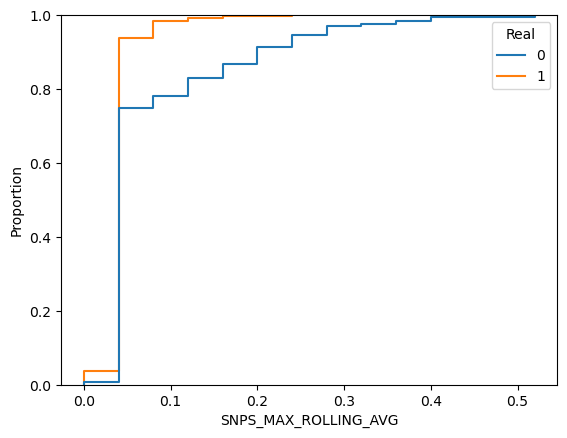

In [142]:
sns.ecdfplot(data=df_train,
             x='SNPS_MAX_ROLLING_AVG',
             hue='Real'
            )

In [135]:
df_train.query("pred_class==1 & Real==0")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'DP', 'Lineage', 'Region', 'SAF', 'SAR', 'SNPS_MAX_ROLLING_AVG']]




,pid,SampleID,POS,REF,ALT,AF,DP,Lineage,Region,SAF,SAR,SNPS_MAX_ROLLING_AVG
77,T0223,MFS-132,1380268,C,T,0.950000,281,2,sugB,138,52,0.04
132,T0247,MFS-160,3265586,A,T,0.950000,305,4,ppsD,178,101,0.04
134,T0247,MFS-160,3527982,G,C,0.251232,203,4,PPE53,32,24,0.08
135,T0247,MFS-160,3527991,G,A,0.158974,195,4,PPE53,19,22,0.08
136,T0247,MFS-160,3717219,C,G,0.137457,291,4,sugI,25,16,0.04
195,T0004,MFS-2,3742991,A,G,0.052133,211,2,NC_2579,4,4,0.08
223,T0047,MFS-27,4211206,G,A,0.047809,251,4,tcrX,7,5,0.00
275,T0292,MFS-310,4130682,A,G,0.390000,278,4,Rv3689,43,44,0.12
276,T0292,MFS-310,4130683,T,C,0.380000,278,4,Rv3689,35,45,0.08
277,T0292,MFS-310,4130694,T,C,0.280000,300,4,Rv3689,41,45,0.12


In [128]:
# 2881590 is a region with 2 homopolymeric tracts. One has an insertion and the other has a deletion
# 4130682, 4130683, and 4130694 are within an 18 base pair insertion
df_train.query("pred_class==1 & Real==0 & SampleID not in ['MFS-310', 'MFS-311']")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'DP', 'Lineage', 'Region', 'SAF', 'SAR']]

,pid,SampleID,POS,REF,ALT,AF,DP,Lineage,Region,SAF,SAR
132,T0247,MFS-160,3265586,A,T,0.950000,305,4,ppsD,178,101
134,T0247,MFS-160,3527982,G,C,0.251232,203,4,PPE53,32,24
135,T0247,MFS-160,3527991,G,A,0.158974,195,4,PPE53,19,22
136,T0247,MFS-160,3717219,C,G,0.137457,291,4,sugI,25,16
195,T0004,MFS-2,3742991,A,G,0.052133,211,2,NC_2579,4,4
223,T0047,MFS-27,4211206,G,A,0.047809,251,4,tcrX,7,5
448,T0070,MFS-41,1921453,T,G,0.950000,224,2,NC_1315,113,94
522,T0017,MFS-520,1415097,C,G,0.550000,352,1,pknH,92,126
523,T0017,MFS-520,3527982,G,C,0.174312,218,1,PPE53,30,12
524,T0017,MFS-520,3527991,G,A,0.073892,203,1,PPE53,23,10


In [10]:
df_train.query("SampleID=='MFS-7'").query("pred_class==1")[['POS', 'REF', 'ALT', 'AF', 'BQ', 'MQ', 'SAF_prop_deviation_from_half', 'Real']]

,POS,REF,ALT,AF,BQ,MQ,SAF_prop_deviation_from_half,Real
636,167717,T,C,0.430000,33,60,0.085586,1
637,1506744,G,C,0.430000,33,60,0.000000,1
638,2267551,C,T,0.065359,33,60,0.150000,1
641,2755424,G,A,0.057377,33,60,0.125000,1
642,2819006,T,C,0.081761,33,60,0.220000,1
643,3296843,A,G,0.950000,29,58,0.124277,0


In [12]:
sample = 'MFS-286'
df_stats = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/pilon/lowAF_SNVs_aln_stats.csv")
df_stats['SAF_prop_deviation_from_half'] = np.abs(0.5 - (df_stats['SAF'] / (df_stats['SAF'] + df_stats['SAR'])))


In [123]:
sample = 'MFS-286'

df_SNPs_with_density = compute_sites_with_high_lowAF_SNP_density(f"{H37Rv_ref_dir}/{sample}/pilon/lowAF_SNVs.csv",
                                                                 f"{H37Rv_ref_dir}/{sample}/pilon/{sample}_SNPs.excludeLowConf.vcf.gz",
                                                                )

ValueError: cannot convert float NaN to integer

In [101]:
# df_samples = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples.tsv", sep='\t', header=None)

In [122]:
# df_samples.to_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples.tsv", sep='\t', header=None, index=False)



In [120]:
sample = 'MFS-311'
df_stats = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/pilon/lowAF_SNVs_aln_stats.csv")

In [121]:
df_stats[['POS', 'REF', 'ALT', 'SNPS_MAX_ROLLING_AVG']].merge(df_train.query("SampleID==@sample")[['POS', 'pred_class', 'Real']])

,POS,REF,ALT,SNPS_MAX_ROLLING_AVG,pred_class,Real
0,219056,G,C,0.04,1,1
1,1114754,G,A,0.04,1,1
2,1955228,C,T,0.04,1,1
3,2881590,G,T,0.24,1,0
4,2881593,C,G,0.20,0,0
5,2881594,A,C,0.16,1,0
6,2881595,C,A,0.16,1,0
7,2881597,A,C,0.20,1,0
8,2955114,G,A,0.04,1,1
9,3411240,G,A,0.04,1,1


In [101]:
def compute_sites_with_high_lowAF_SNP_density(df_SNPs, AF_min=0.05, AF_max=0.95, SNP_window_size=100):
    
    variant_sites = df_SNPs.POS.values
    df_SNPs['SNP'] = 1

    # only need sites around the candidate low AF variants, which we've already filtered. This will speed up the computation
    ref_sites = list(set(np.arange(df_SNPs.POS.min() - SNP_window_size, df_SNPs.POS.max() + SNP_window_size)) - set(df_SNPs.POS))

    df_SNPs = pd.concat([df_SNPs,
                         pd.DataFrame({'POS': ref_sites, 'SNP': 0})
                        ]).sort_values("POS").reset_index(drop=True)

    assert sum(pd.isnull(df_SNPs['SNP'])) == 0

    df_SNPs['SNPS_LEFT_ROLLING_AVG'] = df_SNPs['SNP'].rolling(window=SNP_window_size, min_periods=1, closed='right').mean()
    df_SNPs['SNPS_RIGHT_ROLLING_AVG'] = df_SNPs['SNP'][::-1].rolling(window=SNP_window_size, min_periods=1, closed='right').mean()[::-1]

    # take the maximum at each site
    df_SNPs['SNPS_MAX_ROLLING_AVG'] = np.max([df_SNPs['SNPS_LEFT_ROLLING_AVG'], df_SNPs['SNPS_RIGHT_ROLLING_AVG']], axis=0)
    
    del df_SNPs['SNP']

    # just need the SNP densities computed at each variant site in the original dataframe
    return df_SNPs.query("POS in @variant_sites")

In [123]:
sample = 'MFS-310'
df_stats = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/pilon/lowAF_SNVs_aln_stats.csv")

In [125]:
df_stats[['POS', 'SNPS_MAX_ROLLING_AVG', 'DISCORDANT_READS_RATIO', 'AF']]

,POS,SNPS_MAX_ROLLING_AVG,DISCORDANT_READS_RATIO,AF
0,2881590,0.20,0.010101,0.169550
1,2881593,0.16,0.010067,0.170732
2,2881594,0.12,0.010033,0.173145
3,2881595,0.16,0.009836,0.173145
4,2881597,0.20,0.009868,0.167832
5,3411240,0.04,0.032154,0.420000
6,4130682,0.12,0.015244,0.390000
7,4130683,0.08,0.015291,0.380000
8,4130694,0.12,0.014535,0.280000


In [126]:
# del_fNames = glob.glob(f"{H37Rv_ref_dir}/*/pilon/lowAF_SNVs_aln_stats.csv")
# len(del_fNames)

767

In [127]:
# for fName in del_fNames:
#     os.remove(fName)

In [124]:
df_stats[['POS', 'SNPS_MAX_ROLLING_AVG', 'DISCORDANT_READS_RATIO']]

,POS,SNPS_MAX_ROLLING_AVG,DISCORDANT_READS_RATIO
0,2881590,0.20,0.010101
1,2881593,0.16,0.010067
2,2881594,0.12,0.010033
3,2881595,0.16,0.009836
4,2881597,0.20,0.009868
5,3411240,0.04,0.032154
6,4130682,0.12,0.015244
7,4130683,0.08,0.015291
8,4130694,0.12,0.014535


In [122]:
df_pilon_confusion_matrix.query("SampleID==@sample & Result=='TP'")

,POS,REF,ALT,AF,H37Rv_POS,H37Rv_REF,H37Rv_ALT,H37Rv_AF,Result,SampleID,pid,F2,Lineage,Region
308,3411240.0,G,A,0.42,3411240.0,G,A,0.42,TP,MFS-310,T0292,0.010262,4,Rv3050c


In [51]:
df_train.query("pred_class==1 & Real==0 & SampleID in ['MFS-310', 'MFS-311']")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'DP', 'Lineage', 'Region', 'SAF', 'SAR']]



,pid,SampleID,POS,REF,ALT,AF,DP,Lineage,Region,SAF,SAR
269,T0292,MFS-310,2881590,G,T,0.169550,289,4,Rv2561,22,19
270,T0292,MFS-310,2881593,C,G,0.170732,287,4,Rv2561,26,14
271,T0292,MFS-310,2881594,A,C,0.173145,283,4,Rv2561,25,19
272,T0292,MFS-310,2881595,C,A,0.173145,283,4,Rv2561,26,20
273,T0292,MFS-310,2881597,A,C,0.167832,286,4,Rv2561,22,20
275,T0292,MFS-310,4130682,A,G,0.390000,278,4,Rv3689,43,44
276,T0292,MFS-310,4130683,T,C,0.380000,278,4,Rv3689,35,45
277,T0292,MFS-310,4130694,T,C,0.280000,300,4,Rv3689,41,45
281,T0292,MFS-311,2881590,G,T,0.178261,230,4,Rv2561,22,10
283,T0292,MFS-311,2881594,A,C,0.185841,226,4,Rv2561,20,11


In [58]:
exclude_regions = pd.read_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/references/BED_files/exclude_regions_50bp.EBRlessThan95Percent.bed", sep='\t', header=None, names=['CHROM', 'BEG', 'END'])

In [52]:
df_train.query("pred_class==1 & Real==0 & Region in ['PPE53']")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'DP', 'Lineage', 'Region', 'SAF', 'SAR']]


,pid,SampleID,POS,REF,ALT,AF,DP,Lineage,Region,SAF,SAR
134,T0247,MFS-160,3527982,G,C,0.251232,203,4,PPE53,32,24
135,T0247,MFS-160,3527991,G,A,0.158974,195,4,PPE53,19,22
523,T0017,MFS-520,3527982,G,C,0.174312,218,1,PPE53,30,12
524,T0017,MFS-520,3527991,G,A,0.073892,203,1,PPE53,23,10


In [49]:
df_trust_patients.query("SampleID in ['MFS-310', 'MFS-311']")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_meth,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week
781,T0292,S0292-01,MFS-310,MFS-310_lib52351,NaN,NaN,1.0,310.12,0.99,0.9895,...,11.0,9.0,2.0,0.242329,NaN,0.010262,4.8,4.2.1.1.1.1.1.1.i1,4,1
782,T0292,S0292-08,MFS-311,MFS-311_lib52352,NaN,NaN,1.0,261.64,0.99,0.9869,...,11.0,9.0,2.0,0.242329,NaN,0.010974,4.8,4.2.1.1.1.1.1.1.i1,4,8


In [40]:
df_train.columns

Index(['CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'FILTER', 'DP', 'TD', 'BQ', 'MQ',
       'BC', 'IC', 'DC', 'XC', 'AF', 'AO', 'Mean_BQ_ALT_allele', 'SAF', 'SAR',
       'COV', 'COV_MAX_ROLLING_AVG', 'CLIPPED_BASES', 'DISCORDANT_READS',
       'COV_RATIO', 'DISCORDANT_READS_RATIO', 'CLIPPED_BASES_RATIO',
       'SampleID', 'COV_RATIO_DIFF_FROM_1', 'pid', 'Coll2014', 'Freschi2020',
       'Lineage', 'F2', 'SAF_prop_deviation_from_half', 'Real',
       'False_in_all_Ground_Truth_Samples', 'predicted', 'pred_class',
       'Region'],
      dtype='object')

In [17]:
df_train.AF.min(), df_train.AF.max()

(0.0452261306532663, 0.95)

In [18]:
df_val.AF.min(), df_val.AF.max()

(0.045016077170418, 0.95)

In [24]:
fixed_model_results.loc[fixed_model_results['p.value'] < 0.05]

,term,estimate,std.error,statistic,p.value,conf.low,conf.high
0,(Intercept),1.801261,0.229589,2.563218,1.037069e-02,1.092304,2.752868
1,COV_RATIO_DIFF_FROM_1,0.566696,0.180704,-3.142892,1.672876e-03,0.393463,0.803343
2,CLIPPED_BASES_RATIO,0.580575,0.233807,-2.325576,2.004119e-02,0.339374,0.852292
3,DISCORDANT_READS_RATIO,0.041000,0.376056,-8.493886,1.998398e-17,0.016938,0.077087
4,Mean_BQ_ALT_allele,2.344096,0.157652,5.403659,6.529513e-08,1.748694,3.268110
5,SAF_prop_deviation_from_half,0.565904,0.148468,-3.834702,1.257164e-04,0.420401,0.755432


In [12]:
SNP_data_files = glob.glob(f"{H37Rv_ref_dir}/*/pilon/lowAF_SNVs_aln_stats.csv")

df_candidate_SNPs = []

for fName in SNP_data_files:

    match = re.search(r'MFS-\d{1,3}', fName)

    df = pd.read_csv(fName).query("REF.str.len() == ALT.str.len()")        
    df['SampleID'] = match.group()
    df_candidate_SNPs.append(df)

df_candidate_SNPs = pd.concat(df_candidate_SNPs).query("DP >= 5")

In [19]:
ground_truth_SNP_data_files = glob.glob(f"{personal_ref_dir}/*/pilon/ground_truth.csv")
samples_with_ground_truth = os.listdir(personal_ref_dir)

df_ground_truth = []

for fName in ground_truth_SNP_data_files:

    match = re.search(r'MFS-\d{1,3}', fName)

    df = pd.read_csv(fName).query("REF.str.len() == ALT.str.len()")

    df['SampleID'] = match.group()
    df_ground_truth.append(df)

df_ground_truth = pd.concat(df_ground_truth).merge(df_trust_patients[['pid', 'SampleID', 'Coll2014', 'Freschi2020', 'Lineage', 'F2']], on='SampleID', how='left').query("F2 <= @F2_max")

In [22]:
df_ground_truth.shape

(447, 22)

In [121]:
model_dir = "./pilonVariantDetector/unmixed_only"

df_train = pd.read_csv(f"{model_dir}/training_data_with_predictions.csv")
df_val = pd.read_csv(f"{model_dir}/validation_data_with_predictions.csv")

len(df_train), len(df_val)

(951, 2888)

In [131]:
model_dir = "../lowAF_variant_calling/variantDetector/unmixed_only"

df_train_freebayes = pd.read_csv(f"{model_dir}/training_data_with_predictions_fixed_effects_only.csv")

In [177]:
df_train.query("POS in @rRNA_pos & POS in @insertion_seqs_phages_pos").columns

Index(['CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'FILTER', 'DP', 'TD', 'BQ', 'MQ',
       'BC', 'IC', 'DC', 'XC', 'AF', 'AO', 'Mean_BQ_ALT_allele', 'SAF', 'SAR',
       'COV', 'COV_MAX_ROLLING_AVG', 'CLIPPED_BASES', 'DISCORDANT_READS',
       'COV_RATIO', 'DISCORDANT_READS_RATIO', 'CLIPPED_BASES_RATIO',
       'SampleID', 'COV_RATIO_DIFF_FROM_1', 'pid', 'Coll2014', 'Freschi2020',
       'Lineage', 'F2', 'SAF_prop_deviation_from_half', 'Real',
       'False_in_all_Ground_Truth_Samples', 'predicted', 'pred_class'],
      dtype='object')

In [170]:
df_train.query("SampleID=='MFS-1'")[['SampleID', 'POS', 'REF', 'ALT', 'SAF', 'SAR', 'AO', 'SAF_prop_deviation_from_half', 'Real', 'COV_RATIO', 'DISCORDANT_READS_RATIO']].query("POS==2591484")

,SampleID,POS,REF,ALT,SAF,SAR,AO,SAF_prop_deviation_from_half,Real,COV_RATIO,DISCORDANT_READS_RATIO
2,MFS-1,2591484,G,A,154,184,285,0.044379,0,0.956306,0.230263


In [191]:
df_train.query("Real==1 & SAF_prop_deviation_from_half > 0.2")[['SampleID', 'POS', 'REF', 'ALT', 'DP', 'SAF', 'SAR', 'AO', 'SAF_prop_deviation_from_half', 'Real', 'COV_RATIO', 'CLIPPED_BASES_RATIO', 'Mean_BQ_ALT_allele']].sort_values('SAF_prop_deviation_from_half').merge(df_train_freebayes[['SampleID', 'POS']])

,SampleID,POS,REF,ALT,DP,SAF,SAR,AO,SAF_prop_deviation_from_half,Real,COV_RATIO,CLIPPED_BASES_RATIO,Mean_BQ_ALT_allele
0,MFS-132,2327250,G,A,250,5,12,15,0.205882,1,0.916975,0.003390,31.764706
1,MFS-611,2112499,G,A,211,12,5,10,0.205882,1,1.000270,0.003861,34.000000
2,MFS-71,4022436,G,A,223,4,10,13,0.214286,1,0.881382,0.000000,33.428571
3,MFS-56,720755,C,T,236,13,5,18,0.222222,1,0.954808,0.018797,34.000000
4,MFS-411,253394,C,T,218,5,13,15,0.222222,1,0.945917,0.003717,31.888889
5,MFS-17,1005132,A,G,261,11,4,14,0.233333,1,0.965096,0.000000,34.000000
6,MFS-7,2819006,T,C,318,7,21,26,0.250000,1,0.954764,0.003012,33.214286
7,MFS-756,962477,G,T,190,3,10,11,0.269231,1,0.948961,0.004505,40.000000
8,MFS-355,3823833,T,C,285,17,5,19,0.272727,1,1.015185,0.005571,34.000000
9,MFS-22,1454297,A,G,253,3,12,12,0.300000,1,1.045892,0.006061,34.000000


In [229]:
df_compare = df_train[['SampleID', 'POS', 'REF', 'ALT', 'SAF', 'SAR', 'AO', 'AF', 'SAF_prop_deviation_from_half', 'Real']].merge(df_train_freebayes[['SampleID', 'POS', 'REF', 'ALT', 'SAF', 'SAR', 'AO', 'AF', 'SAF_prop_deviation_from_half']], on=['SampleID', 'POS', 'REF', 'ALT'])

df_compare['Strand_Bias_Diff'] = np.abs(df_compare['SAF_prop_deviation_from_half_y'] - df_compare['SAF_prop_deviation_from_half_x'])

df_compare['Weird_POS'] = (df_compare['POS']==2591484).astype(int)

len(df_compare)

592

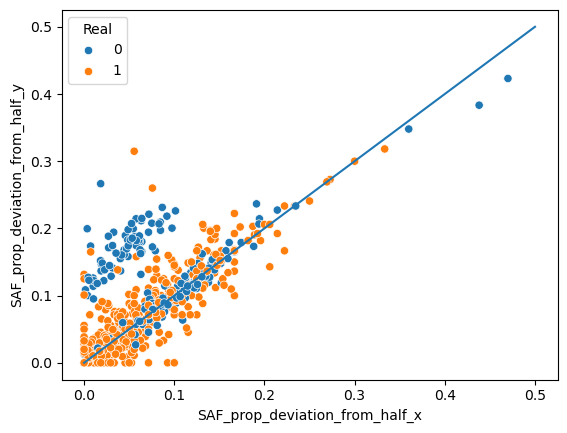

In [213]:
fig, ax = plt.subplots()

sns.scatterplot(data=df_compare,
                x='SAF_prop_deviation_from_half_x',
                y='SAF_prop_deviation_from_half_y',
                hue='Real',
                ax=ax
               )

x_vals = np.linspace(0, 0.5, 5)
plt.plot(x_vals, x_vals)

<Axes: xlabel='Strand_Bias_Diff', ylabel='Count'>

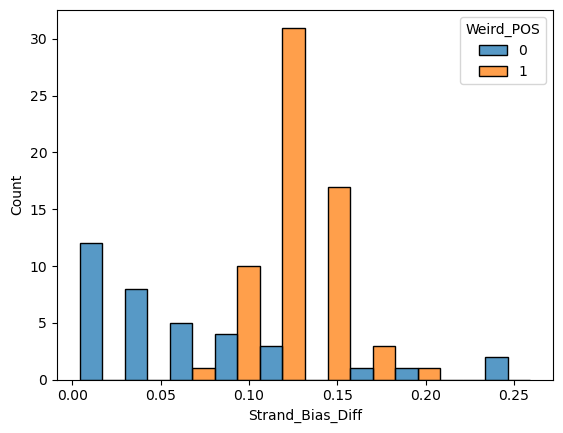

In [237]:
sns.histplot(data=df_compare.query("SAF_prop_deviation_from_half_x < 0.1 & SAF_prop_deviation_from_half_y > 0.1"),
             x='Strand_Bias_Diff',
             hue='Weird_POS',
             multiple='dodge'
            )

In [241]:
df_compare.query("SAF_prop_deviation_from_half_x < 0.1 & SAF_prop_deviation_from_half_y > 0.1")[['SampleID', 'POS', 'REF', 'ALT', 'SAF_prop_deviation_from_half_x', 'SAF_x', 'SAR_x', 'SAF_prop_deviation_from_half_y', 'SAF_y', 'SAR_y', 'Strand_Bias_Diff', 'Real']]

,SampleID,POS,REF,ALT,SAF_prop_deviation_from_half_x,SAF_x,SAR_x,SAF_prop_deviation_from_half_y,SAF_y,SAR_y,Strand_Bias_Diff,Real
1,MFS-1,2591484,G,A,0.044379,154,184,0.168000,83,167,0.123621,0
12,MFS-110,1629722,C,T,0.071429,12,9,0.111111,11,7,0.039683,1
13,MFS-110,2591484,G,A,0.056338,126,158,0.188073,68,150,0.131735,0
24,MFS-113,2591484,G,A,0.032819,121,138,0.194301,59,134,0.161482,0
27,MFS-113,3394672,G,A,0.075758,14,19,0.260000,6,19,0.184242,1
...,...,...,...,...,...,...,...,...,...,...,...,...
552,MFS-7,2591484,G,A,0.097484,128,190,0.200389,77,180,0.102905,0
559,MFS-71,2591484,G,A,0.071856,143,191,0.221116,70,181,0.149259,0
582,MFS-8,2591484,G,A,0.053314,155,192,0.185393,84,183,0.132079,0
584,MFS-80,2591484,G,A,0.003472,143,145,0.199482,58,135,0.196010,0


In [251]:
df_train.query("POS==2591484")[['SampleID', 'POS', 'REF', 'ALT', 'AF', 'Real', 'DISCORDANT_READS_RATIO', 'predicted', 'pred_class']]#.pred_class.value_counts()

,SampleID,POS,REF,ALT,AF,Real,DISCORDANT_READS_RATIO,predicted,pred_class
2,MFS-1,2591484,G,A,0.70,0,0.230263,0.006813,0
18,MFS-110,2591484,G,A,0.68,0,0.189409,0.024554,0
30,MFS-113,2591484,G,A,0.62,0,0.248120,0.003768,0
37,MFS-115,2591484,G,A,0.61,0,0.227006,0.011477,0
42,MFS-116,2591484,G,A,0.66,0,0.227626,0.007162,0
...,...,...,...,...,...,...,...,...,...
927,MFS-761,2591484,G,A,0.63,0,0.206169,0.029622,0
933,MFS-768,2591484,G,A,0.71,0,0.227991,0.011287,0
937,MFS-8,2591484,G,A,0.66,0,0.260615,0.003440,0
940,MFS-80,2591484,G,A,0.60,0,0.233929,0.008404,0


In [232]:
len(df_compare.query("SAF_prop_deviation_from_half_x < 0.1 & SAF_prop_deviation_from_half_y > 0.1 & POS==2591484"))

63

In [260]:
sample = 'MFS-132'
pos = 1380268
alt_allele = 'T'


(138, 52)

In [286]:
df_samples = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv")

In [317]:
df_samples.to_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv", index=False)

In [294]:
df_SR_samples = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples.tsv", sep='\t', header=None)

In [316]:
df_SR_samples.to_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples.tsv", sep='\t', header=None, index=False)

In [292]:
df_compare.query("SAF_prop_deviation_from_half_x < 0.1 & SAF_prop_deviation_from_half_y > 0.1 & POS!=2591484 & Real==0").sort_values('Strand_Bias_Diff').tail(1)

,SampleID,POS,REF,ALT,SAF_x,SAR_x,AO_x,AF_x,SAF_prop_deviation_from_half_x,Real,SAF_y,SAR_y,AO_y,AF_y,SAF_prop_deviation_from_half_y,Strand_Bias_Diff,Weird_POS
68,MFS-132,1380268,C,T,155,144,263,0.95,0.018395,0,151,46,197,0.942584,0.266497,0.248103,0


In [307]:
df_test = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/MFS-132/pilon/lowAF_SNVs_aln_stats.csv")
df_test.query("POS==1380268")[['POS', 'REF', 'ALT', 'SAF', 'SAR', 'AO', 'Mean_BQ_ALT_allele']]

,POS,REF,ALT,SAF,SAR,AO,Mean_BQ_ALT_allele
3,1380268,C,T,138.0,52.0,263,28.207358


In [277]:
for i, row in df_compare.query("SAF_prop_deviation_from_half_x < 0.1 & SAF_prop_deviation_from_half_y > 0.1 & POS!=2591484")[['SampleID', 'POS', 'REF', 'ALT', 'SAF_prop_deviation_from_half_x', 'SAF_x', 'SAR_x', 'SAF_prop_deviation_from_half_y', 'SAF_y', 'SAR_y', 'Strand_Bias_Diff', 'Real']].iterrows():
    
    sample = row['SampleID']
    pos = row['POS']
    alt_allele = row['ALT']
    
    bam = pysam.AlignmentFile(f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam", "rb")

    mean_base_qual, SAF, SAR = compute_mean_base_quality_strand_support_of_variant(bam, pos, alt_allele, chrom='Chromosome')
    
    print(mean_base_qual, row['SAF_prop_deviation_from_half_x'], np.abs(0.5 - SAF / (SAF + SAR)), row['SAF_prop_deviation_from_half_y'])

32.19047619047619 0.0714285714285714 0.1470588235294118 0.111111111111111
31.636363636363637 0.0757575757575757 0.13636363636363635 0.26
33.30964467005076 0.0939086294416244 0.11016949152542371 0.10752688172043
28.207357859531772 0.0183946488294314 0.22631578947368425 0.266497461928934
31.28421052631579 0.0578947368421052 0.16216216216216217 0.157894736842105
32.84615384615385 0.0576923076923077 0.06818181818181823 0.108695652173913
33.63636363636363 0.0909090909090909 0.11904761904761907 0.119047619047619
32.516129032258064 0.0806451612903226 0.11538461538461542 0.12962962962963
31.5 0.0 0.07894736842105265 0.131578947368421
32.51546391752577 0.077319587628866 0.11538461538461536 0.123529411764706
33.19298245614035 0.0789473684210527 0.10204081632653061 0.107476635514019
33.50666666666667 0.0966666666666667 0.10076045627376429 0.100706713780919
27.466666666666665 0.0555555555555556 0.35185185185185186 0.314814814814815
33.15862068965517 0.0793103448275862 0.10655737704918034 0.1044776

In [6]:
del_fNames = glob.glob(f"{H37Rv_ref_dir}/*/pilon/lowAF*")
len(del_fNames)

1534

In [8]:
for fName in del_fNames:
    os.remove(fName)

In [313]:
del_fNames = glob.glob(f"{personal_ref_dir}/*/pilon/lowAF*")
len(del_fNames)

3

In [315]:
for fName in del_fNames:
    os.remove(fName)

In [276]:
def compute_mean_base_quality_strand_support_of_variant(bam, pos, low_freq_allele, chrom='Chromosome'):
        
    base_qualities_low_freq_allele = []
    SAF = 0
    SAR = 0

    # default min_base_quality is 13, so bad reads get excluded, which negates the purpose of this function...rolls eyes. min_mapping_quality default is 0
    # but use the mapping quality filter here
    for pileupcolumn in bam.pileup(chrom, pos-1, pos, truncate=True, min_base_quality=0, min_mapping_quality=0):

        for pileupread in pileupcolumn.pileups:
            if pileupread.is_del or pileupread.is_refskip:
                continue  # skip deletions and skipped regions

            aln = pileupread.alignment

            if not aln.is_secondary and not aln.is_supplementary and aln.is_paired and aln.is_proper_pair:
    
                base = aln.query_sequence[pileupread.query_position]
                base_qual = aln.query_qualities[pileupread.query_position]
                map_qual = aln.mapping_quality

                # include only properly paired reads when computing strand bias and base quality
                if base == low_freq_allele:
                    base_qualities_low_freq_allele.append(base_qual)

                    # only include reads in the SAF and SAR count if they meet base and mapping quality minimums
                    # this is to emulate freebayes behavior, where we use BQ ≥ 30 and MQ ≥ 30
                    if base_qual >= 30 and map_qual >= 30:
                        if aln.is_reverse:
                            SAR += 1
                        else:
                            SAF += 1
                
    # no reads passed
    if len(base_qualities_low_freq_allele) == 0:
        return 0, SAF, SAR
    else:
        return np.mean(base_qualities_low_freq_allele), SAF, SAR
    
    
    
def compute_strand_support_of_variant(bam, pos, low_freq_allele, chrom='Chromosome'):
        
    SAF = 0
    SAR = 0
    
    # for freebayes, we use min_mapping_quality and min_base_quality of 30, which is what's used to determine SAF and SAR
    for pileupcolumn in bam.pileup(chrom, pos-1, pos, truncate=True, min_base_quality=30, min_mapping_quality=30):
        
        for pileupread in pileupcolumn.pileups:
            if pileupread.is_del or pileupread.is_refskip:
                continue  # skip deletions and skipped regions

            aln = pileupread.alignment
            
            if not aln.is_secondary and not aln.is_supplementary and aln.is_paired and aln.is_proper_pair:

                base = aln.query_sequence[pileupread.query_position]
                qual = aln.query_qualities[pileupread.query_position]

                # include only properly paired reads when computing strand bias and base quality
                if base == low_freq_allele:
                    if aln.is_reverse:
                        SAR += 1
                    else:
                        SAF += 1

    return SAF, SAR
    
    
    
    
def compute_mean_base_quality_of_variant(bam, pos, low_freq_allele, chrom='Chromosome'):
        
    base_qualities_low_freq_allele = []
    
    # default min_base_quality is 13, so bad reads get excluded, which negates the purpose of this function...rolls eyes. min_mapping_quality default is 0
    for pileupcolumn in bam.pileup(chrom, pos-1, pos, truncate=True, min_base_quality=0):

        for pileupread in pileupcolumn.pileups:
            if pileupread.is_del or pileupread.is_refskip:
                continue  # skip deletions and skipped regions

            aln = pileupread.alignment
            
            if not aln.is_secondary and not aln.is_supplementary and aln.is_paired and aln.is_proper_pair:

                base = aln.query_sequence[pileupread.query_position]
                qual = aln.query_qualities[pileupread.query_position]

                # include only properly paired reads when computing strand bias and base quality
                if base == low_freq_allele:
                    base_qualities_low_freq_allele.append(qual)
            
    # no reads passed
    if len(base_qualities_low_freq_allele) == 0:
        return 0
    else:
        return np.mean(base_qualities_low_freq_allele)


<Axes: xlabel='SAF_prop_deviation_from_half', ylabel='Count'>

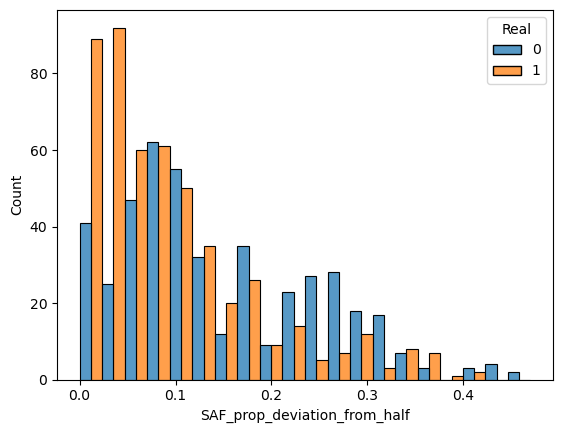

In [129]:
sns.histplot(data=df_train,#.query("pred_class==1 & Real==0"),
             x='SAF_prop_deviation_from_half',
             hue='Real',
             multiple='dodge'
            )

In [105]:
df_train[['COV_RATIO', 'COV_RATIO_DIFF_FROM_1']].query("COV_RATIO > 1")

,COV_RATIO,COV_RATIO_DIFF_FROM_1
9,1.008131,0.008131
25,1.029088,0.029088
35,1.008946,0.008946
41,1.050682,0.050682
44,1.051248,0.051248
...,...,...
920,1.032709,0.032709
922,1.030013,0.030013
932,1.029005,0.029005
940,1.011214,0.011214


<Axes: xlabel='COV_RATIO', ylabel='COV_RATIO_DIFF_FROM_1'>

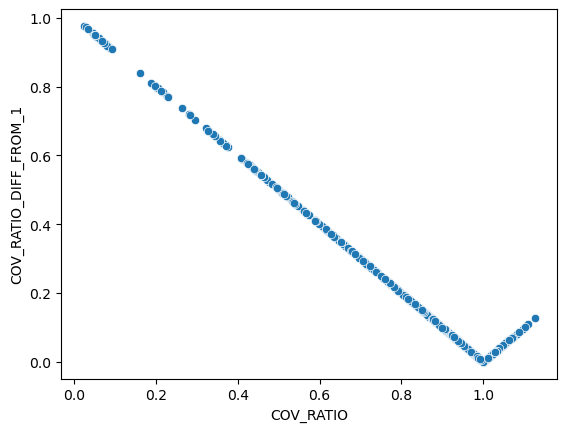

In [106]:
sns.scatterplot(data=df_train,
                x='COV_RATIO',
                y='COV_RATIO_DIFF_FROM_1'
               )

In [110]:
df_train.COV_RATIO.max(), df_val.COV_RATIO.max()

(1.1263467189030365, 1.2219156484036264)

In [114]:
df_train.query("COV_RATIO > 1.1")[['SampleID', 'POS', 'COV_RATIO', 'Real']]

,SampleID,POS,COV_RATIO,Real
189,MFS-162,1519558,1.105996,1
378,MFS-310,4130694,1.109713,0
395,MFS-311,4130694,1.126347,0
748,MFS-520,3566943,1.102004,0


<Axes: xlabel='COV_RATIO', ylabel='COV_RATIO_DIFF_FROM_1'>

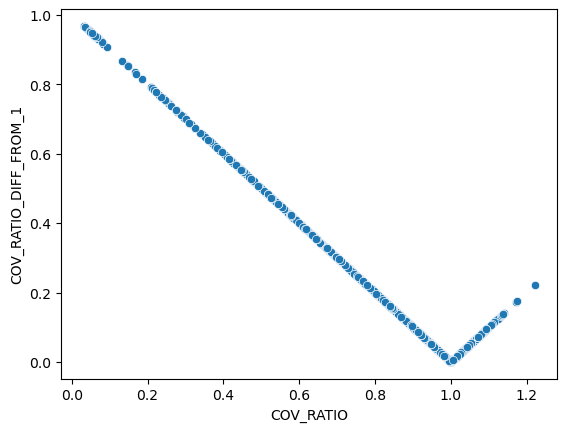

In [108]:
sns.scatterplot(data=df_val,
                x='COV_RATIO',
                y='COV_RATIO_DIFF_FROM_1'
               )

In [97]:
df_train.query("POS >= 2338065 & POS <= 2340874")

,CHROM,POS,REF,ALT,QUAL,FILTER,DP,TD,BQ,MQ,...,SampleID,COV_RATIO_DIFF_FROM_1,pid,Coll2014,Freschi2020,Lineage,F2,SAF_prop_deviation_from_half,Real,False_in_all_Ground_Truth_Samples


In [101]:
df_train.query("POS in [2032214, 2032215]")[['SampleID', 'POS', 'REF', 'ALT', 'AF']]

,SampleID,POS,REF,ALT,AF
310,MFS-28,2032214,T,C,0.93
311,MFS-28,2032215,T,C,0.92
321,MFS-29,2032214,T,C,0.48
322,MFS-29,2032215,T,C,0.42


In [103]:
df_train.query("SampleID=='MFS-737'")[['SampleID', 'POS', 'REF', 'ALT', 'AF']]

,SampleID,POS,REF,ALT,AF
908,MFS-737,997899,C,T,0.69


In [57]:
df_pilon_confusion_matrix.query("Result=='FN'").sort_values('AF')

,POS,REF,ALT,AF,H37Rv_POS,H37Rv_REF,H37Rv_ALT,H37Rv_AF,Result,SampleID,pid,F2,Region
487,3959484.0,T,A,0.045226,NaN,NaN,NaN,NaN,FN,MFS-318,T0311,0.012310,NaN
965,2701028.0,G,A,0.045307,NaN,NaN,NaN,NaN,FN,MFS-7,T0018,0.010706,NaN
169,216020.0,T,A,0.045455,NaN,NaN,NaN,NaN,FN,MFS-16,T0031,0.010009,NaN
865,2352215.0,T,C,0.045455,NaN,NaN,NaN,NaN,FN,MFS-58,T0107,0.010080,NaN
888,365429.0,C,T,0.048077,NaN,NaN,NaN,NaN,FN,MFS-611,T0156,0.010995,NaN
98,1899383.0,T,C,0.048338,NaN,NaN,NaN,NaN,FN,MFS-132,T0223,0.010359,NaN
569,356582.0,A,T,0.048649,NaN,NaN,NaN,NaN,FN,MFS-328,T0285,0.012589,NaN
24,454568.0,A,T,0.054878,NaN,NaN,NaN,NaN,FN,MFS-113,T0198,0.009842,NaN
507,4180002.0,G,C,0.062893,NaN,NaN,NaN,NaN,FN,MFS-320,T0321,0.012366,NaN
296,851061.0,C,G,0.064935,NaN,NaN,NaN,NaN,FN,MFS-264,T0290,0.013014,NaN


In [79]:
df = pd.read_csv(f"{H37Rv_ref_dir}/MFS-135/pilon/lowAF_SNVs_aln_stats.csv")

In [73]:
np.abs(1 - df['COV_RATIO'])

0    0.241357
1    0.008989
2    0.061846
3    0.071155
4    0.488409
Name: COV_RATIO, dtype: float64

In [81]:
df.query("POS >= 2338065 & POS <= 2340874")

,CHROM,POS,REF,ALT,QUAL,FILTER,DP,TD,BQ,MQ,...,Mean_BQ_ALT_allele,SAF,SAR,COV,COV_MAX_ROLLING_AVG,CLIPPED_BASES,DISCORDANT_READS,COV_RATIO,DISCORDANT_READS_RATIO,CLIPPED_BASES_RATIO
1,Chromosome,2338275,G,C,3549.0,PASS,392,422,33,59,...,32.415584,57.0,20.0,442,499.00,1,42,0.885772,0.095023,0.002262
2,Chromosome,2338810,T,C,9318.0,Amb,571,587,33,59,...,33.035398,184.0,42.0,678,692.28,14,21,0.979373,0.030973,0.020649
3,Chromosome,2338811,A,G,9615.0,Amb,590,607,33,59,...,33.637168,184.0,42.0,679,691.69,15,21,0.981654,0.030928,0.022091
4,Chromosome,2338866,T,G,2693.0,Amb,605,615,33,60,...,33.109948,146.0,45.0,682,684.40,10,20,0.996493,0.029326,0.014663
5,Chromosome,2338912,A,C,3208.0,Amb,549,569,33,60,...,32.304094,126.0,45.0,640,690.55,20,18,0.926797,0.028125,0.031250
6,Chromosome,2338961,G,A,5411.0,Amb,539,549,31,60,...,28.506608,153.0,74.0,660,682.34,10,12,0.967260,0.018182,0.015152
7,Chromosome,2339240,G,A,2910.0,PASS,439,445,34,58,...,33.443396,196.0,228.0,577,732.38,2,22,0.787842,0.038128,0.003466
8,Chromosome,2339255,A,G,8151.0,PASS,435,439,33,58,...,33.225420,223.0,194.0,501,693.92,2,13,0.721985,0.025948,0.003992


In [78]:
df_pilon_confusion_matrix.query("Lineage=='3' & Result=='FP'")

,POS,REF,ALT,AF,H37Rv_POS,H37Rv_REF,H37Rv_ALT,H37Rv_AF,Result,SampleID,pid,F2,Lineage,Region
112,NaN,NaN,NaN,NaN,2095835.0,C,G,0.064286,FP,MFS-135,T0225,0.009854,3,blaR
113,NaN,NaN,NaN,NaN,2338275.0,G,C,0.183673,FP,MFS-135,T0225,0.009854,3,Rv2081c
114,NaN,NaN,NaN,NaN,2338810.0,T,C,0.370000,FP,MFS-135,T0225,0.009854,3,Rv2082
115,NaN,NaN,NaN,NaN,2338811.0,A,G,0.370000,FP,MFS-135,T0225,0.009854,3,Rv2082
116,NaN,NaN,NaN,NaN,2338866.0,T,G,0.280000,FP,MFS-135,T0225,0.009854,3,Rv2082
117,NaN,NaN,NaN,NaN,2338912.0,A,C,0.290000,FP,MFS-135,T0225,0.009854,3,Rv2082
118,NaN,NaN,NaN,NaN,2338961.0,G,A,0.330000,FP,MFS-135,T0225,0.009854,3,Rv2082
119,NaN,NaN,NaN,NaN,2339240.0,A,G,0.200000,FP,MFS-135,T0225,0.009854,3,Rv2082
120,NaN,NaN,NaN,NaN,2339255.0,G,A,0.110000,FP,MFS-135,T0225,0.009854,3,Rv2082
131,NaN,NaN,NaN,NaN,236075.0,G,T,0.060000,FP,MFS-15,T0030,0.014411,3,zmp1


In [70]:
pd.DataFrame(df_pilon_confusion_matrix.query("Result=='FP'").Region.value_counts())#.loc['Rv2081c']

,count
Region,
Rv2319c,99
uspC,71
Rv2082,56
NC_2234,25
Rv0376c,19
...,...
zmp1,1
fadD8,1
Rv1120c,1


In [67]:
df_pilon_confusion_matrix.query("Result=='FP' & H37Rv_POS >= 2338065 & H37Rv_POS <= 2340874")

,POS,REF,ALT,AF,H37Rv_POS,H37Rv_REF,H37Rv_ALT,H37Rv_AF,Result,SampleID,pid,F2,Region
113,NaN,NaN,NaN,NaN,2338275.0,G,C,0.183673,FP,MFS-135,T0225,0.009854,Rv2081c
114,NaN,NaN,NaN,NaN,2338810.0,T,C,0.370000,FP,MFS-135,T0225,0.009854,Rv2082
115,NaN,NaN,NaN,NaN,2338811.0,A,G,0.370000,FP,MFS-135,T0225,0.009854,Rv2082
116,NaN,NaN,NaN,NaN,2338866.0,T,G,0.280000,FP,MFS-135,T0225,0.009854,Rv2082
117,NaN,NaN,NaN,NaN,2338912.0,A,C,0.290000,FP,MFS-135,T0225,0.009854,Rv2082
...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,NaN,NaN,NaN,NaN,2338866.0,T,G,0.280000,FP,MFS-737,T0096,0.011066,Rv2082
987,NaN,NaN,NaN,NaN,2338912.0,A,C,0.270000,FP,MFS-737,T0096,0.011066,Rv2082
988,NaN,NaN,NaN,NaN,2338961.0,G,A,0.310000,FP,MFS-737,T0096,0.011066,Rv2082
989,NaN,NaN,NaN,NaN,2339240.0,A,G,0.200000,FP,MFS-737,T0096,0.011066,Rv2082


In [3]:
df_freebayes_lowAF_SNVs = []

for i, sample in enumerate(ground_truth_samples):
    
    # df = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/ground_truth.csv")
    
    # the BED files only contain variants with an AF \in [0.05, 0.95]
    df = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.excludeLowConf.bed", 
                     sep='\t', 
                     header=None,
                     names=['CHROM', 'H37Rv_BEG', 'H37RV_END', 'Original', 'Score', 'Sense']
                    )
    
    df['POS'] = df['H37Rv_BEG'] + 1

    # df = df.query("AF >= 0.05 & AF <= 0.95 & POS not in @insertion_seqs_phages_pos & POS not in @rRNA_pos")
    df = df.query("POS not in @insertion_seqs_phages_pos & POS not in @rRNA_pos")
    df['SampleID'] = sample
    df['VarLen'] = df['H37RV_END'] - df['H37Rv_BEG']
    
    df_freebayes_lowAF_SNVs.append(df.query("VarLen==1"))
    # df_freebayes_lowAF_SNVs.append(df.query("REF.str.len() == ALT.str.len()"))

df_freebayes_lowAF_SNVs = pd.concat(df_freebayes_lowAF_SNVs).drop_duplicates(['SampleID', 'POS'], keep='last').merge(df_trust_patients[['pid', 'SampleID', 'F2']], how='left')
df_freebayes_lowAF_SNVs['Region'] = df_freebayes_lowAF_SNVs['POS'].map(h37Rv_coords_dict)

df_freebayes_lowAF_SNVs = df_freebayes_lowAF_SNVs.query("F2 <= @F2_max").reset_index(drop=True)



# df_ground_truth_lowAF_SNPs_summary = pd.DataFrame(df_freebayes_lowAF_SNVs.groupby(['pid', 'SampleID', 'F2'])['POS'].count().reset_index().rename(columns={'POS': 'NumSNPs'}))

# df_ground_truth_lowAF_SNPs_summary = pd.concat([df_ground_truth_lowAF_SNPs_summary,
#                                               df_trust_patients.query("SampleID in @ground_truth_samples & SampleID not in @df_ground_truth_lowAF_SNPs_summary.SampleID")[['pid', 'SampleID', 'F2']]
#                                              ])

# df_ground_truth_lowAF_SNPs_summary['NumSNPs'] = df_ground_truth_lowAF_SNPs_summary['NumSNPs'].fillna(0).astype(int)

# df_ground_truth_lowAF_SNPs_summary['SameSample'] = df_ground_truth_lowAF_SNPs_summary['SampleID'].isin(df_assemblies_QC.Illumina_ID.values).astype(int)

In [4]:
df_pilon_lowAF_SNVs = []

for i, sample in enumerate(ground_truth_samples):
    
    # df = pd.read_csv(f"{personal_ref_dir}/{sample}/pilon/ground_truth.csv")
    
    # the BED files only contain variants with an AF \in [0.05, 0.95]
    df = pd.read_csv(f"{personal_ref_dir}/{sample}/pilon/lowAF_SNVs.H37Rv.excludeLowConf.bed", 
                     sep='\t', 
                     header=None,
                     names=['CHROM', 'H37Rv_BEG', 'H37RV_END', 'Original', 'Score', 'Sense']
                    )
    
    df['POS'] = df['H37Rv_BEG'] + 1

    # df = df.query("AF >= 0.05 & AF <= 0.95 & POS not in @insertion_seqs_phages_pos & POS not in @rRNA_pos")
    df.query("POS not in @insertion_seqs_phages_pos & POS not in @rRNA_pos")
    df['SampleID'] = sample
    
    df['VarLen'] = df['H37RV_END'] - df['H37Rv_BEG']
        
    df_pilon_lowAF_SNVs.append(df.query("VarLen==1"))
    # df_pilon_lowAF_SNVs.append(df.query("REF.str.len() == ALT.str.len()"))

df_pilon_lowAF_SNVs = pd.concat(df_pilon_lowAF_SNVs).drop_duplicates(['SampleID', 'POS'], keep='last').merge(df_trust_patients[['pid', 'SampleID', 'F2']], how='left')
df_pilon_lowAF_SNVs['Region'] = df_pilon_lowAF_SNVs['POS'].map(h37Rv_coords_dict)

df_pilon_lowAF_SNVs = df_pilon_lowAF_SNVs.query("F2 <= @F2_max").reset_index(drop=True)




# df_ground_truth_lowAF_SNPs_summary = pd.DataFrame(df_freebayes_lowAF_SNVs.groupby(['pid', 'SampleID', 'F2'])['POS'].count().reset_index().rename(columns={'POS': 'NumSNPs'}))

# df_ground_truth_lowAF_SNPs_summary = pd.concat([df_ground_truth_lowAF_SNPs_summary,
#                                               df_trust_patients.query("SampleID in @ground_truth_samples & SampleID not in @df_ground_truth_lowAF_SNPs_summary.SampleID")[['pid', 'SampleID', 'F2']]
#                                              ])

# df_ground_truth_lowAF_SNPs_summary['NumSNPs'] = df_ground_truth_lowAF_SNPs_summary['NumSNPs'].fillna(0).astype(int)

# df_ground_truth_lowAF_SNPs_summary['SameSample'] = df_ground_truth_lowAF_SNPs_summary['SampleID'].isin(df_assemblies_QC.Illumina_ID.values).astype(int)

In [5]:
len(df_pilon_lowAF_SNVs), len(df_freebayes_lowAF_SNVs)

(514, 401)

In [6]:
df_compare = df_pilon_lowAF_SNVs[['SampleID', 'POS']].rename(columns={'POS': 'pilon_POS'}).merge(df_freebayes_lowAF_SNVs[['SampleID', 'POS']].rename(columns={'POS': 'freebayes_POS'}), how='outer', left_on=['SampleID', 'pilon_POS'], right_on=['SampleID', 'freebayes_POS'])

len(df_compare)


519

In [7]:
df_pilon_found = df_compare.loc[pd.isnull(df_compare['freebayes_POS'])].rename(columns={'pilon_POS': 'POS'})[['SampleID', 'POS']].merge(df_pilon_lowAF_SNVs)[['pid', 'SampleID', 'POS',  'Region']]

len(df_pilon_found)

118

In [10]:
df_pilon_found.Region.value_counts()

Region
NC_983     3
pirG       3
embR       2
PPE52      2
mshB       2
          ..
Rv3091     1
NC_2779    1
Rv0681     1
recC       1
Rv1461     1
Name: count, Length: 107, dtype: int64

In [8]:
df_freebayes_found = df_compare.loc[pd.isnull(df_compare['pilon_POS'])].rename(columns={'freebayes_POS': 'POS'})[['SampleID', 'POS']].merge(df_freebayes_lowAF_SNVs)[['pid', 'SampleID', 'POS', 'Region']]

len(df_freebayes_found)

5

In [157]:
df_freebayes_found

,pid,SampleID,POS,Region
0,T0188,MFS-106,1271358,Rv1144
1,T0220,MFS-129,1860116,pheT
2,T0223,MFS-132,1904560,Rv1680
3,T0223,MFS-132,1380268,sugB
4,T0070,MFS-41,1921453,NC_1315


In [12]:
# differential_detected_AF = np.concatenate([df_pilon_found.AF.values, df_freebayes_found.AF.values])
# len(differential_detected_AF)

(array([72.,  2.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  1.]),
 array([0.05      , 0.08796578, 0.12593156, 0.16389734, 0.20186312,
        0.2398289 , 0.27779468, 0.31576046, 0.35372624, 0.39169202,
        0.42965779]),
 <BarContainer object of 10 artists>)

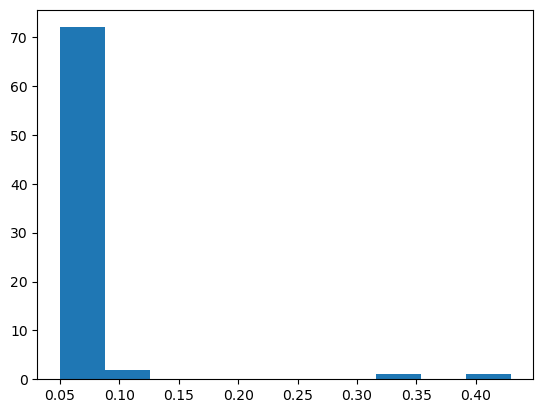

In [32]:
plt.hist(differential_detected_AF)

(array([29., 20.,  8.,  4.,  5.,  1.,  2.,  1.,  0.,  2.]),
 array([0.05      , 0.05349673, 0.05699346, 0.0604902 , 0.06398693,
        0.06748366, 0.07098039, 0.07447712, 0.07797386, 0.08147059,
        0.08496732]),
 <BarContainer object of 10 artists>)

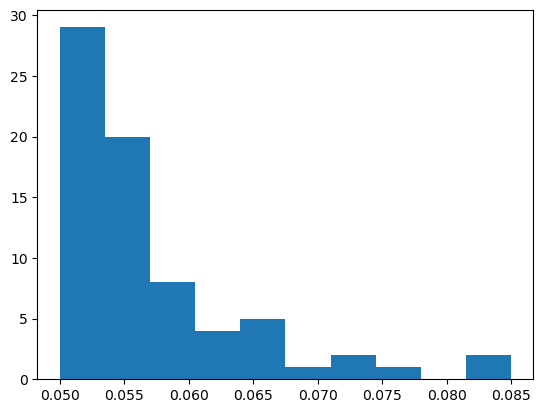

In [35]:
plt.hist(differential_detected_AF[differential_detected_AF <= 0.1])

In [33]:
df_pilon_found.query("AF > 0.1")

,pid,SampleID,POS,REF,ALT,AF,Region
29,T0284,MFS-325,1699255,T,C,0.429658,Rv1508c
32,T0284,MFS-326,1699255,T,C,0.320675,Rv1508c
48,T0013,MFS-5,4274543,G,C,0.107955,pirG


In [34]:
df_freebayes_found.query("AF > 0.1")

,pid,SampleID,POS,REF,ALT,AF,Region
10,T0338,MFS-410,1595145,A,G,0.119205,uvrC


In [ ]:
filter_high_quality_lowAF_variants(vcf_file, bam_file, depth_file, output_file, save_BED=False)

In [38]:
sample = 'MFS-410'
depth_file = f"{personal_ref_dir}/{sample}/bam/{sample}.depth.tsv.gz"
df_depth = pd.read_csv(depth_file, sep='\t', header=None, compression='gzip')

In [39]:
df_depth[2].median() / 2

133.5

In [41]:
df_depth.loc[df_depth[1]==1599467]

,0,1,2
1599466,S0338-01_contig_1_pilon,1599467,161


In [105]:
sample = 'MFS-410'

df_pilon_variants = filter_high_quality_lowAF_variants(f"{personal_ref_dir}/{sample}/pilon/{sample}_SNPs.vcf",
                                       f"{personal_ref_dir}/{sample}/bam/{sample}.markDup.bam",
                                       f"{personal_ref_dir}/{sample}/bam/{sample}.depth.tsv.gz"
                                      )

30116


In [108]:
df_pilon_variants['AF'].max()

0.42

In [100]:
df_pilon_variants.query("POS==1599467")

,CHROM,POS,REF,ALT,QUAL,FILTER,DP,TD,BQ,MQ,BC,IC,DC,XC,AF,AO,AF_rounded,Mean_BQ_ALT_allele,SAF,SAR
0,S0338-01_contig_1_pilon,1599467,A,G,2342.0,PASS,130,131,33,60,"115,0,15,0",0,0,0,0.115385,15.0,0.12,34.0,7.0,11.0


In [115]:
del_fNames = glob.glob(f"{H37Rv_ref_dir}/*/pilon/lowAF_SNVs*")
len(del_fNames)

0

In [ ]:
# for fName in del_fNames:
#     os.remove(fName)

In [109]:
df_personal_samples = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv")

In [118]:
df_personal_samples.to_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv", index=False)

In [104]:
def filter_high_quality_lowAF_variants(vcf_file, bam_file, depth_file):
    
    # VCF file
    df_variants = read_pilon_vcf(vcf_file)
    print(len(df_variants))
    
    int_cols = ['DP', 'IC', 'DC', 'BQ', 'MQ', 'TD']

    for col in int_cols:
        df_variants[col] = df_variants[col].astype(int)

    df_variants['AF'] = df_variants['AF'].astype(float)
    
    df_variants = df_variants.query("~(AF > 0.95)")
    return df_variants

    df_fixed_variants = df_variants.query("ALT!='.'")
    df_unfixed_variants = df_variants.query("ALT=='.'")

    # need AO columns for both groups
    # df_fixed_variants[['ALT', 'AO']] = df_fixed_variants.apply(lambda row: get_alt_allele(row["BC"], row["REF"]), axis=1, result_type="expand")
    df_unfixed_variants[['ALT', 'AO']] = df_unfixed_variants.apply(lambda row: get_alt_allele(row["BC"], row["REF"]), axis=1, result_type="expand")

    # recompute new AF only for the variants with NA in the ALT and AF columns. Make use of pilon's output AF because it is weighted by base and mapping qualities
    df_unfixed_variants['AF'] = df_unfixed_variants['AO'] / df_unfixed_variants['DP']
    
    # recombine
    df_variants = pd.concat([df_fixed_variants, df_unfixed_variants]).sort_values("POS").reset_index(drop=True)

    # apply QC filters
    df_lowAF_variants = apply_pilon_lowAF_QCfilters(df_variants).reset_index(drop=True)
    
    chrom = df_lowAF_variants.CHROM.unique()[0]
    bam = pysam.AlignmentFile(bam_file, "rb")
        
    # the base quality (BQ) column in pilon is the average BQ of all reads at the site. Need BQ of reads that support the variant
    for i, row in df_lowAF_variants.iterrows():
        mean_base_qual, SAF, SAR = compute_mean_base_quality_strand_support_of_variant(bam, row['POS'], row['ALT'], chrom=chrom)
        df_lowAF_variants.loc[i, ['Mean_BQ_ALT_allele', 'SAF', 'SAR']] = [mean_base_qual, SAF, SAR]
        
    assert sum(pd.isnull(df_lowAF_variants['Mean_BQ_ALT_allele'])) == 0
    
    # require at least 2 forward and 2 reverse reads for each variant
    df_lowAF_variants = df_lowAF_variants.query("Mean_BQ_ALT_allele >= 20 & SAF >= 2 & SAR >= 2")

    # require that all low-AF variants occur in areas where the depth is at least half the median depth
    df_depth = pd.read_csv(depth_file, compression='gzip', header=None, sep='\t', names=['CHROM','POS', 'DEPTH'])

    depth_min = df_depth['DEPTH'].median() / 2
    print(depth_min)
    return df_lowAF_variants
    # depth_max = df_depth['DEPTH'].median() * 2

    # for the personal genome-aligned variants, use DP. For H37Rv-aligned variants, use TD. TD is more permissive because it includes improperly paired reads
    # Use TD for H37Rv-aligned variants to be more permissive because we risk losing some real variants that are present at low AF
    # the linear mixed model will take care of issues with depth and discordant reads
    # the save_BED switch is True for personal genome-aligned files and False for H37Rv-aligned files
    df_lowAF_variants = df_lowAF_variants.query("TD >= @depth_min")
    
    # no 'RO' anymore
    save_cols = ['DP', 'TD', 'BQ', 'MQ', 'BC', 'IC', 'DC', 'XC', 'AF', 'AO', 'Mean_BQ_ALT_allele', 'SAF', 'SAR']
    
    return df_lowAF_variants[['CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'FILTER'] + save_cols]